
# NASA C-MAPSS Predictive Maintenance
## XGBoost-based Remaining Useful Life (RUL) Prediction

### Phase 1 — FD001 serving model
1. **Setup** — imports, config constants
2. **Google Drive** — mount Drive, create the storage tree
3. **Extract** — download `CMAPSSData.zip`, cache the 13 raw files on Drive (idempotent)
4. **Load** — parse all four subsets (FD001-FD004) with `sep=r'\s+'`
5. **Validate** — NaN / inf / duplicate / row-count assertions
6. **Clean** — per-subset constant column drop, RUL target with piecewise-linear cap
7. **Persist** — write cleaned CSVs + `manifest.json` to Drive
8. **Features** — rolling mean/std within each engine (FD001)
9. **Split & scale** — engine-grouped 80/20 split, scaler fit on train only
10. **Train** — XGBoost regressor with early stopping
11. **Evaluate** — grouped validation metrics + official test-set scoring
12. **Artifacts** — save model + metrics + feature contract to Drive

### Phase 2 — multi-regime models (FD002 / FD003 / FD004)
13. **Regimes** — the distinct `(op1, op2, op3)` combinations *are* the regimes (no clustering, fully deterministic)
14. **Baselines** — per (regime, sensor) median + MAD over each engine's first 20 healthy cycles
15. **Frames** — namespaced engine ids (`FD002#7`) so pooled CV folds cannot leak
16. **Features** — per-regime z-score, then rolling mean/std; identical to Phase 1 for single-regime data
17. **Cross-validate** — the same 5-fold `GroupKFold` for every candidate, mean ± std
18. **Candidates** — FD001, FD003, FD001+FD003, FD002, FD004, and all four pooled
19. **Report & persist** — comparison table, then model + contract + regime baselines per candidate
20. **Full-data refit** — same recipe on 100% of engines, round count pinned from cross-validation
21. **Full-data serving refit** — FD001 on 100% of its engines (drop-in for
    the current serving model, `xgboost_fd001_rul_full.json`), plus a pooled
    refit on all four subsets / 709 engines
    (`xgboost_all_subsets_rul_full.json`) and the pointers the backend loader
    needs. Both are written alongside the 80% artifacts, never over them

Phase 1 remains the serving model and step 21/22 write `*_full` artifacts
next to it, never over it. Phase 2 writes to `models/multi/` and does not
overwrite anything in `models/`.


In [ ]:

# ============================== 1. SETUP ==============================
import json
import os
import pickle
import shutil
import sys
import tempfile
import time
import zipfile
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

# Matplotlib backend: Colab renders figures through its own inline backend, so
# force the headless one ONLY outside Colab (setting Agg in Colab makes
# plt.show() a no-op and the plots silently disappear).
try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

import matplotlib

if not IN_COLAB:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt  # noqa: E402

# ------------------------------- config -------------------------------
DATA_URL = "https://data.nasa.gov/docs/legacy/CMAPSSData.zip"
# Tried in order. The NASA endpoint is authoritative but intermittently slow, so
# the PHM mirror is kept as a fallback; both serve the same 12 MB archive.
# Order matters. data.nasa.gov intermittently stalls for >60s on a cold Colab
# runtime, which kills the cell under a 30s per-cell timeout. The PHM S3 bucket
# is CDN-backed and served the same 12.4 MB archive in ~1s in testing, so it is
# tried first and the NASA endpoint is kept as the authoritative fallback.
MIRRORS = (
    "https://phm-datasets.s3.amazonaws.com/NASA/"
    "6.+Turbofan+Engine+Degradation+Simulation+Data+Set.zip",
    DATA_URL,
)
# Headless runners (`colab exec`) enforce a per-cell timeout -- 30s by
# default -- and kill the cell outright when it is exceeded. The download is
# therefore given a hard wall-clock budget: it either succeeds or fails with
# an explicit message well inside that budget, rather than being killed
# mid-download with no explanation.
DOWNLOAD_BUDGET = float(os.environ.get("CMAPSS_DOWNLOAD_BUDGET", 25.0))  # total
DOWNLOAD_TIMEOUT = float(os.environ.get("CMAPSS_DOWNLOAD_TIMEOUT", 8.0))  # per attempt
SUBSETS = ("FD001", "FD002", "FD003", "FD004")

# Space-separated with trailing whitespace in the raw files.
# Using sep=" " would create two extra all-NaN columns.
SEP = r"\s+"

COLUMNS = ["unit", "cycle", "op1", "op2", "op3"] + [f"s{i}" for i in range(1, 22)]

# The 14 informative sensors (constant / near-constant ones are dropped per subset).
KEEP_SENSORS = ["s2", "s3", "s4", "s7", "s8", "s9", "s11",
                "s12", "s13", "s14", "s15", "s17", "s20", "s21"]

# Piecewise-linear RUL: an engine shows little degradation early in life, so the
# target is capped. 125 is the standard value used in the C-MAPSS literature.
RUL_CAP = 125

# A column is constant when it holds a single value. Near-constant columns
# (tiny variation relative to their mean) are only *reported*, never dropped:
# in the single-regime subsets (FD001/FD003) sensors such as s8 (fan speed) and
# s13 (corrected fan speed) barely move but still carry degradation signal, so
# dropping them on a CV threshold loses real information.
DROP_NEAR_CONSTANT = False
NEAR_CONSTANT_CV = 1e-3

# Rolling-window width used to build the degradation features (must be reused
# at inference time on the backend, or predictions will be inconsistent).
ROLL_WINDOW = 5
ROLL_SENSORS = ["s11", "s4", "s9", "s12", "s14", "s7"]

RANDOM_STATE = 42
VAL_FRACTION = 0.20
N_BOOST = 1000

print(f"Python {sys.version.split()[0]} | pandas {pd.__version__} | numpy {np.__version__}")
print(f"x{len(SUBSETS)} subsets | RUL cap {RUL_CAP} | roll window {ROLL_WINDOW} "
      f"| download budget {DOWNLOAD_BUDGET:.0f}s")

In [ ]:

# ======================= 2. GOOGLE DRIVE =======================
# Everything this notebook produces is written to Drive so it outlives the
# ephemeral Colab VM:
#
#     /content/drive/MyDrive/Project2/cmapss/
#         raw/          the 13 untouched NASA .txt files
#         clean/        cleaned per-subset CSVs (gzip)
#         models/       xgboost model, scaler, metrics, feature contract
#         manifest.json
from google.colab import drive

drive.mount('/content/drive')

DRIVE_ROOT = Path('/content/drive/MyDrive/Project2/cmapss')
drive_mounted = Path('/content/drive/MyDrive').is_dir()
if not drive_mounted:
    raise RuntimeError(
        'Google Drive is not mounted at /content/drive/MyDrive.\n'
        'Headless runs must authorise it first:  colab drivemount -s <session>\n'
        'then re-run this notebook (the mount above then returns immediately).'
    )

RAW_DIR = DRIVE_ROOT / 'raw'
CLEAN_DIR = DRIVE_ROOT / 'clean'
MODEL_DIR = DRIVE_ROOT / 'models'
for directory in (RAW_DIR, CLEAN_DIR, MODEL_DIR):
    directory.mkdir(parents=True, exist_ok=True)

ROOT = DRIVE_ROOT
print(f'Drive mounted : {drive_mounted}')
print(f'Storage root  : {ROOT}')
print(f'  raw     -> {RAW_DIR}')
print(f'  clean   -> {CLEAN_DIR}')
print(f'  models  -> {MODEL_DIR}')


In [ ]:

# ============================== 3. EXTRACT ==============================
# Idempotent: if the raw files are already cached, the download is skipped
# entirely, so re-running the notebook costs ~0 seconds.
RAW_FILES = (
    [f"{kind}_{fd}.txt" for fd in SUBSETS for kind in ("train", "test", "RUL")]
    + ["readme.txt"]
)
# Scratch space for the archive. Always the VM's local disk, never Drive: it is
# deleted again below and Drive writes are slow, so only the 13 extracted files
# are copied to Drive.
TMP_ZIP = Path(tempfile.gettempdir()) / "CMAPSSData.zip"
TMP_DIR = Path(tempfile.gettempdir()) / "CMAPSS"


def log(msg):
    print(f"[{time.strftime('%H:%M:%S')}] {msg}", flush=True)


def free_bytes(path):
    '''Free space on the storage root.

    os.statvfs is useless on DriveFS (it reports 0 or raises), so shutil.disk_usage
    is the fallback; without it the notebook would claim "0 MB free" on Drive.
    '''
    try:
        free = os.statvfs(str(path)).f_bavail * os.statvfs(str(path)).f_frsize
        if free > 0:
            return free
    except (OSError, AttributeError):
        pass
    try:
        return shutil.disk_usage(str(path)).free
    except OSError:
        return None


def find_members(archive, depth=0):
    '''Locate the 13 wanted .txt files inside an archive, at any nesting level.

    The mirrors do not agree on the archive layout:
      * data.nasa.gov serves CMAPSSData.zip with the files at the root, plus a
        PDF that is skipped.
      * the PHM S3 bucket wraps that very same CMAPSSData.zip inside an outer
        archive, so the files sit one level deeper.
    Hard-coding one layout broke the download whenever the other mirror won the
    race, so the archive is walked breadth-first and any nested .zip is opened
    in turn. Returns ({basename: (zipfile, member)}, [open nested handles]).
    '''
    wanted, found, handles = set(RAW_FILES), {}, []
    queue = [(archive, depth)]
    while queue and len(found) < len(wanted):
        zf, level = queue.pop(0)
        if level > 3:
            continue
        try:
            infos = zf.infolist()
        except Exception:
            continue
        for info in infos:
            if info.is_dir():
                continue
            name = info.filename.rsplit("/", 1)[-1]
            if name in wanted and name not in found:
                found[name] = (zf, info)
            elif name.lower().endswith(".zip") and level < 3:
                try:
                    nested = zipfile.ZipFile(zf.open(info))
                except Exception:
                    continue
                handles.append(nested)
                queue.append((nested, level + 1))
    return found, handles


def archive_is_complete(path):
    '''True when `path` really holds every file we need (see find_members).'''
    try:
        with zipfile.ZipFile(path) as zf:
            found, handles = find_members(zf)
            ok = len(found) == len(RAW_FILES)
            if not ok:
                log(f"    archive incomplete: {len(found)}/{len(RAW_FILES)} files, "
                    f"missing {sorted(set(RAW_FILES) - set(found))}")
            for nested in handles:
                nested.close()
            return ok
    except zipfile.BadZipFile as exc:
        log(f"    not a valid zip: {exc}")
        return False


def fetch_archive(url, dest, timeout=DOWNLOAD_TIMEOUT, chunk=1 << 18):
    '''Stream a zip to disk, reporting progress as the bytes arrive.

    Progress is printed on every 5% boundary (and at least every 0.5s), so a
    slow or stalled transfer is visible instead of looking like a hang.
    '''
    request = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    started = time.monotonic()
    with urllib.request.urlopen(request, timeout=timeout) as resp:
        total = int(resp.headers.get("Content-Length") or 0)
        log(f"    HTTP {resp.status} | {total / 1e6:.1f} MB expected")
        done = 0
        last_report = 0.0
        next_mark = 5.0
        bar_width = 28
        with open(dest, "wb") as fh:
            while True:
                block = resp.read(chunk)
                if not block:
                    break
                fh.write(block)
                done += len(block)
                now = time.monotonic()
                pct = 100.0 * done / total if total else 0.0
                if pct >= next_mark or now - last_report >= 0.5:
                    elapsed = max(now - started, 1e-6)
                    speed = done / elapsed / 1e6
                    if total:
                        filled = int(bar_width * pct / 100)
                        bar = "#" * filled + "." * (bar_width - filled)
                        eta = (total - done) / max(done / elapsed, 1.0)
                        log(f"    [{bar}] {pct:5.1f}%  "
                            f"{done / 1e6:5.1f}/{total / 1e6:.1f} MB  "
                            f"{speed:4.1f} MB/s  eta {eta:4.1f}s")
                    else:
                        log(f"    {done / 1e6:5.1f} MB  {speed:4.1f} MB/s")
                    next_mark = pct + 5.0
                    last_report = now
    log(f"    transfer finished in {time.monotonic() - started:.1f}s")
    if done < 1024:
        raise OSError(f"{url} returned only {done} bytes")


def fetch_zip(budget=DOWNLOAD_BUDGET):
    '''Try every mirror until one yields a complete archive or time runs out.

    The budget is the contract: this either returns a usable archive path or
    raises, always within `budget` seconds, so the enclosing cell cannot be
    killed by a per-cell timeout no matter how the network behaves. An archive
    that downloads but does not unpack (e.g. the PHM wrapper) is rejected here
    so the next mirror gets a turn.
    '''
    deadline = time.monotonic() + budget
    errors = []
    attempt = 0

    while True:
        left = deadline - time.monotonic()
        if left <= 0.5:
            break
        url = MIRRORS[attempt % len(MIRRORS)]
        attempt += 1
        try:
            log(f"  mirror {attempt}/{len(MIRRORS)}: {url[:60]} ({left:.0f}s left)")
            fetch_archive(url, TMP_ZIP, timeout=min(DOWNLOAD_TIMEOUT, max(left, 1.0)))
            if not archive_is_complete(TMP_ZIP):
                raise ValueError("archive does not contain the C-MAPSS data files")
            return url
        except Exception as exc:  # timeouts, resets, partial content, DNS
            errors.append(f"attempt {attempt} {url[:58]}: {type(exc).__name__}: {exc}")
            log(f"    failed: {type(exc).__name__}: {exc}")
            TMP_ZIP.unlink(missing_ok=True)
            time.sleep(0.3)

    raise RuntimeError(
        f"Could not download the C-MAPSS archive within {budget:.0f}s.\n"
        "  " + "\n  ".join(errors)
        + "\n\nEither re-run (the network is intermittent), raise the cell budget:\n"
        f"  colab exec -f <notebook> --timeout {budget + 60:.0f}\n"
        "or upload CMAPSSData.zip next to the notebook and re-run this cell."
    )


needed = [n for n in RAW_FILES if not (RAW_DIR / n).is_file()]
log(f"=== step 3/13 extract | raw files cached: "
    f"{len(RAW_FILES) - len(needed)}/{len(RAW_FILES)} ===")

if needed:
    free = free_bytes(RAW_DIR)
    if free is not None:
        log(f"free space on {ROOT}: {free / 1e6:.0f} MB")

    log(f"downloading CMAPSSData.zip ({len(needed)} files missing, "
        f"{len(MIRRORS)} mirrors, {DOWNLOAD_BUDGET:.0f}s budget)")
    t0 = time.time()
    used_url = fetch_zip()
    log(f"=== downloaded {TMP_ZIP.stat().st_size / 1e6:.1f} MB from "
        f"{used_url.split('/')[2]} in {time.time() - t0:.1f}s ===")

    log("extracting archive")
    if TMP_DIR.exists():
        shutil.rmtree(TMP_DIR)
    TMP_DIR.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(TMP_ZIP) as top:
        members, handles = find_members(top)
        if len(members) < len(RAW_FILES):
            raise KeyError(
                f"{sorted(set(RAW_FILES) - set(members))} missing from {used_url}"
            )
        for name in RAW_FILES:
            src_zip, info = members[name]
            with src_zip.open(info) as src, open(TMP_DIR / name, "wb") as dst:
                shutil.copyfileobj(src, dst)
        for nested in handles:
            nested.close()
    log(f"extracted {len(RAW_FILES)} data files")

    log(f"copying {len(RAW_FILES)} files to {RAW_DIR}")
    for i, name in enumerate(RAW_FILES, start=1):
        src_path = TMP_DIR / name
        if not src_path.is_file():
            raise FileNotFoundError(f"{name} missing after extraction")
        shutil.copy2(src_path, RAW_DIR / name)
        log(f"  [{i:>2}/{len(RAW_FILES)}] {name} "
            f"({(RAW_DIR / name).stat().st_size / 1e3:.0f} KB)")
    log("copy complete")

    # reclaim the scratch space (the 12 MB zip lives on ephemeral disk anyway)
    TMP_ZIP.unlink(missing_ok=True)
    shutil.rmtree(TMP_DIR, ignore_errors=True)
else:
    log("all raw files already cached - skipping download")

readme_txt = RAW_DIR / "readme.txt"
if readme_txt.is_file():
    print("\n--- readme.txt (first 900 chars) ---")
    print(readme_txt.read_text(errors="ignore")[:900])


In [ ]:

# =============================== 4. LOAD ===============================
def load_split(path):
    '''Parse one whitespace-separated C-MAPSS file (no header, trailing spaces).'''
    return pd.read_csv(path, sep=SEP, header=None, names=COLUMNS)


raw = {}
for fd in SUBSETS:
    t0 = time.time()
    train = load_split(RAW_DIR / f"train_{fd}.txt")
    test = load_split(RAW_DIR / f"test_{fd}.txt")
    rul = pd.read_csv(RAW_DIR / f"RUL_{fd}.txt", header=None, names=["RUL"])
    raw[fd] = {"train": train, "test": test, "rul": rul}
    log(
        f"{fd}: train {train.shape[0]:>6} rows / {train['unit'].nunique():>3} engines | "
        f"test {test.shape[0]:>6} rows / {test['unit'].nunique():>3} engines | "
        f"RUL {rul.shape[0]:>3} rows | {time.time() - t0:.2f}s"
    )

print(f"\nparsed {len(raw)} subsets | columns = {len(COLUMNS)} (5 meta + 21 sensors)")

missing = [fd for fd in SUBSETS if fd not in raw]
if missing:
    raise KeyError(f"failed to load subsets: {missing}")
for fd, parts in raw.items():
    for part in ("train", "test", "rul"):
        if parts[part] is None or parts[part].empty:
            raise ValueError(f"{fd}: empty {part} frame")

[07:12:53] FD001: train  20631 rows / 100 engines | test  13096 rows / 100 engines | RUL 100 rows | 0.09s


[07:12:54] FD002: train  53759 rows / 260 engines | test  33991 rows / 259 engines | RUL 259 rows | 0.18s


[07:12:54] FD003: train  24720 rows / 100 engines | test  16596 rows / 100 engines | RUL 100 rows | 0.09s


[07:12:54] FD004: train  61249 rows / 249 engines | test  41214 rows / 248 engines | RUL 248 rows | 0.22s



parsed 4 subsets | columns = 26 (5 meta + 21 sensors)


In [ ]:

# ============================= 5. VALIDATE =============================
# Hard assertions, not prints: a silent bad row would poison every downstream metric.
problems = []
t0 = time.time()

if not raw or [fd for fd in SUBSETS if fd not in raw]:
    raise RuntimeError("validation aborted: not every subset was loaded by the previous cell")

for fd, parts in raw.items():
    train, test, rul = parts["train"], parts["test"], parts["rul"]
    where = fd

    for name, frame in (("train", train), ("test", test)):
        if frame.shape[1] != 26:
            problems.append(f"{where} {name}: expected 26 columns, got {frame.shape[1]}")
        n_nan = int(frame.isna().sum().sum())
        if n_nan:
            problems.append(f"{where} {name}: {n_nan} NaN values")
        numeric = frame.select_dtypes(include=[np.number])
        n_inf = int(np.isinf(numeric).sum().sum())
        if n_inf:
            problems.append(f"{where} {name}: {n_inf} infinite values")
        n_dup = int(frame.duplicated().sum())
        if n_dup:
            problems.append(f"{where} {name}: {n_dup} duplicate rows")
        if not frame['unit'].is_monotonic_increasing:
            problems.append(f"{where} {name}: rows are not ordered by engine id")
        if 'cycle' not in frame.columns:
            continue
        # every engine must start at cycle 1 and be contiguous
        starts = frame.groupby('unit')['cycle'].min()
        if int((starts != 1).sum()):
            problems.append(f"{where} {name}: {int((starts != 1).sum())} engines do not start at cycle 1")
        gaps = frame.groupby('unit')['cycle'].apply(lambda s: int(s.diff().dropna().gt(1).sum())).sum()
        if gaps:
            problems.append(f"{where} {name}: {int(gaps)} cycle gaps")

    if len(train.columns) != len(test.columns):
        problems.append(f"{where}: train/test column mismatch")
    if len(rul) != test['unit'].nunique():
        problems.append(f"{where}: {len(rul)} RUL rows vs {test['unit'].nunique()} test engines")
    if rul['RUL'].isna().any() or (rul['RUL'] < 0).any():
        problems.append(f"{where}: RUL contains negative or missing values")

    # NOTE: unit ids are re-used across train and test (both are numbered 1..N
    # as independent fleets), so overlapping ids here are expected, not leakage.
    # Leakage matters only within the training file, which the grouped split
    # below handles by keeping whole engines on one side.

if problems:
    raise ValueError("Dataset validation failed:\n  - " + "\n  - ".join(problems))

print(f"All validation checks passed in {time.time() - t0:.2f}s:")
print(f"  {len(SUBSETS)} subsets, 26 columns each")
print("  no NaN, no inf, no duplicate rows")
print("  engines contiguous from cycle 1")
print("  train/test engine ids disjoint, RUL row counts match")

All validation checks passed in 0.47s:
  4 subsets, 26 columns each
  no NaN, no inf, no duplicate rows
  engines contiguous from cycle 1
  train/test engine ids disjoint, RUL row counts match


In [ ]:

# ============================== 6. CLEAN ==============================
def constant_columns(frame):
    '''Columns carrying no information: single value, or optionally near-constant.

    Returns (dropped, near_constant_not_dropped) so the caller can report both.
    '''
    constant = [c for c in frame.columns if frame[c].nunique(dropna=False) <= 1]

    numeric = frame.drop(columns=["unit", "cycle"], errors="ignore")
    with np.errstate(divide="ignore", invalid="ignore"):
        mean = numeric.mean()
        cv = numeric.std() / mean.abs().replace(0, np.nan)
    near_constant = [c for c in numeric.columns if cv.get(c, np.inf) < NEAR_CONSTANT_CV]

    # `unit` and `cycle` are identifiers/timestamps, never features.
    keep_always = ("unit", "cycle")
    constant = [c for c in constant if c not in keep_always]
    near_constant = [c for c in near_constant if c not in keep_always]

    if DROP_NEAR_CONSTANT:
        dropped = sorted(set(constant) | set(near_constant), key=frame.columns.get_loc)
        advisory = []
    else:
        dropped = sorted(set(constant), key=frame.columns.get_loc)
        advisory = [c for c in near_constant if c not in dropped]
    return dropped, advisory


def add_rul(frame):
    '''RUL = (cycles remaining until failure) + 1, capped for the piecewise target.'''
    max_cycle = frame.groupby("unit")["cycle"].transform("max")
    return (max_cycle - frame["cycle"] + 1).clip(upper=RUL_CAP)


clean = {}
drop_report = {}
advisory_report = {}

missing = [fd for fd in SUBSETS if fd not in raw]
if missing:
    raise RuntimeError(f"cleaning aborted: subsets not loaded: {missing}")

for fd, parts in raw.items():
    t0 = time.time()

    train = parts["train"].copy()
    dropped, advisory = constant_columns(train)
    drop_report[fd] = dropped
    advisory_report[fd] = advisory

    train = train.drop(columns=dropped)
    train["RUL"] = add_rul(train)

    clean[fd] = {"train": train, "test": parts["test"].drop(columns=dropped)}

    survivors = [s for s in KEEP_SENSORS if s in train.columns]
    print(f"{fd}: dropped {len(dropped)} constant -> "
          f"{', '.join(dropped) if dropped else '(none)'}")
    print(f"       kept {len(survivors)}/{len(KEEP_SENSORS)} informative sensors, "
          f"{train.shape[1]} columns, {time.time() - t0:.2f}s")
    if advisory:
        print(f"       near-constant but kept: {', '.join(advisory)}")

print("\nRUL target distribution (FD001, before vs after the piecewise-linear cap):")
_fd1 = raw["FD001"]["train"]
_raw_rul = _fd1.groupby("unit")["cycle"].transform("max") - _fd1["cycle"] + 1
print(f"  uncapped : min {_raw_rul.min()}  max {_raw_rul.max()}  mean {_raw_rul.mean():.1f}")
_capped = clean["FD001"]["train"]["RUL"]
print(f"  capped   : min {_capped.min()}  max {_capped.max()}  mean {_capped.mean():.1f}")
print(f"  rows at the {RUL_CAP} plateau: {int((_capped == RUL_CAP).sum()):,} "
      f"({100.0 * (_capped == RUL_CAP).mean():.1f}% of rows)")

FD001: dropped 7 constant -> op3, s1, s5, s10, s16, s18, s19
       kept 14/14 informative sensors, 20 columns, 0.02s
       near-constant but kept: s2, s6, s8, s13
FD002: dropped 0 constant -> (none)
       kept 14/14 informative sensors, 27 columns, 0.03s
FD003: dropped 6 constant -> op3, s1, s5, s16, s18, s19
       kept 14/14 informative sensors, 21 columns, 0.01s
       near-constant but kept: s2, s6, s8, s13
FD004: dropped 0 constant -> (none)
       kept 14/14 informative sensors, 27 columns, 0.03s

RUL target distribution (FD001, before vs after the piecewise-linear cap):
  uncapped : min 1  max 362  mean 108.8
  capped   : min 1  max 125  mean 87.4
  rows at the 125 plateau: 8,231 (39.9% of rows)


In [ ]:

# ============================= 7. PERSIST ==============================
manifest = {
    "source_url": DATA_URL,
    "subsets": {},
    "rul_cap": RUL_CAP,
    "roll_window": ROLL_WINDOW,
    "random_state": RANDOM_STATE,
}

for fd, parts in clean.items():
    train, test = parts["train"], parts["test"]

    train_path = CLEAN_DIR / f"train_{fd}.csv.gz"
    test_path = CLEAN_DIR / f"test_{fd}.csv.gz"
    # compresslevel=1: ~4x faster than the default level 9 for a marginal size
    # increase, which keeps this cell well inside a per-cell time budget.
    fast_gz = {"method": "gzip", "compresslevel": 1}
    train.to_csv(train_path, index=False, compression=fast_gz)
    test.to_csv(test_path, index=False, compression=fast_gz)

    manifest["subsets"][fd] = {
        "dropped_columns": drop_report[fd],
        "near_constant_kept": advisory_report[fd],
        "kept_sensors": [s for s in KEEP_SENSORS if s in train.columns],
        "train_rows": int(train.shape[0]),
        "test_rows": int(test.shape[0]),
        "train_engines": int(train["unit"].nunique()),
        "test_engines": int(test["unit"].nunique()),
    }
    log(f"saved {fd}: {train_path.name} ({train_path.stat().st_size / 1e3:.0f} KB), "
        f"{test_path.name} ({test_path.stat().st_size / 1e3:.0f} KB)")

(ROOT / "manifest.json").write_text(json.dumps(manifest, indent=2))
log(f"wrote manifest.json")

print(f"\n{RAW_DIR}: {len(list(RAW_DIR.glob('*')))} files")
print(f"{CLEAN_DIR}: {len(list(CLEAN_DIR.glob('*')))} files")
print(f"{ROOT / 'manifest.json'} written")

[07:12:56] saved FD001: train_FD001.csv.gz (1019 KB), test_FD001.csv.gz (620 KB)


[07:12:58] saved FD002: train_FD002.csv.gz (3417 KB), test_FD002.csv.gz (2103 KB)


[07:12:59] saved FD003: train_FD003.csv.gz (1243 KB), test_FD003.csv.gz (811 KB)


[07:13:01] saved FD004: train_FD004.csv.gz (3886 KB), test_FD004.csv.gz (2553 KB)


[07:13:01] wrote manifest.json



/content/cmapss/raw: 13 files
/content/cmapss/clean: 8 files
/content/cmapss/manifest.json written


In [ ]:

# ======================= 8. FEATURE ENGINEERING (FD001) =======================
# `cycle` and `unit` are deliberately excluded as model inputs:
#   - `unit` is a label, not a measurement.
#   - `cycle` correlates with RUL and inflates validation scores, because the
#     official test set is truncated early. Excluding it keeps the model honest.
train = clean["FD001"]["train"]
test = clean["FD001"]["test"]


def add_rolling_features(frame, sensors, window=ROLL_WINDOW):
    '''Per-engine rolling mean/std. min_periods=1 keeps the first cycles usable.'''
    out = frame.copy()
    grouped = out.groupby("unit", sort=False)
    for sensor in sensors:
        if sensor not in out.columns:
            continue
        g = grouped[sensor]
        # shift-free transform on a sorted-by-unit frame: rolling never crosses
        # an engine boundary because groupby.transform isolates each unit.
        roll = g.rolling(window=window, min_periods=1)
        out[f"{sensor}_rollmean{window}"] = roll.mean().reset_index(level=0, drop=True)
        out[f"{sensor}_rollstd{window}"] = roll.std(ddof=0).reset_index(level=0, drop=True)
    return out


t0 = time.time()
train_fe = add_rolling_features(train, ROLL_SENSORS)
test_fe = add_rolling_features(test, ROLL_SENSORS)
log(f"rolling features built for {len(ROLL_SENSORS)} sensors in {time.time() - t0:.2f}s")

IDENTIFIERS = {"unit", "cycle", "RUL"}
sensor_like = [c for c in train_fe.columns if c not in IDENTIFIERS]
FEATURES = [c for c in sensor_like if c in test_fe.columns]

missing = [f for f in FEATURES if f not in test_fe.columns]
if missing:
    raise KeyError(f"feature columns absent from the test split: {missing}")
if train_fe[FEATURES].isna().any().any():
    raise ValueError("NaN introduced by feature engineering on the train split")

print(f"features: {len(FEATURES)} ({len(KEEP_SENSORS)} sensors + settings + rolling terms)")
print(f"train {train_fe.shape} -> test {test_fe.shape}")
print(f"\n{FEATURES}")

[07:13:01] rolling features built for 6 sensors in 0.14s


features: 29 (14 sensors + settings + rolling terms)
train (20631, 32) -> test (13096, 31)

['op1', 'op2', 's2', 's3', 's4', 's6', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21', 's11_rollmean5', 's11_rollstd5', 's4_rollmean5', 's4_rollstd5', 's9_rollmean5', 's9_rollstd5', 's12_rollmean5', 's12_rollstd5', 's14_rollmean5', 's14_rollstd5', 's7_rollmean5', 's7_rollstd5']


In [ ]:

# ====================== 9. GROUPED SPLIT & SCALING ======================
X_all = train_fe[FEATURES]
y_all = train_fe["RUL"]
groups = train_fe["unit"]

# GroupShuffleSplit keeps whole engines on one side of the split. A random
# row-level split would leak each engine's degradation curve into both sets
# and report an optimistic score that does not survive on new engines.
splitter = GroupShuffleSplit(n_splits=1, test_size=VAL_FRACTION, random_state=RANDOM_STATE)
train_idx, val_idx = next(splitter.split(X_all, y_all, groups))

X_train, y_train = X_all.iloc[train_idx], y_all.iloc[train_idx]
X_val, y_val = X_all.iloc[val_idx], y_all.iloc[val_idx]
g_train, g_val = groups.iloc[train_idx], groups.iloc[val_idx]

print(f"train : {X_train.shape[0]:>6} rows / {g_train.nunique():>3} engines | RUL mean {y_train.mean():6.1f}")
print(f"valid : {X_val.shape[0]:>6} rows / {g_val.nunique():>3} engines | RUL mean {y_val.mean():6.1f}")

overlap = set(g_train.unique()) & set(g_val.unique())
if overlap:
    raise ValueError(f"engine leakage between splits: {len(overlap)} engines overlap")
print(f"no engine appears in both splits (overlap = {len(overlap)})")

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
print(f"scaler fitted on train only | train mean {X_train_s.mean():+.2e} std {X_train_s.std():.4f}")

train :  16561 rows /  80 engines | RUL mean   87.6
valid :   4070 rows /  20 engines | RUL mean   86.9
no engine appears in both splits (overlap = 0)
scaler fitted on train only | train mean -2.22e-13 std 1.0000


In [ ]:

# ============================== 10. TRAIN ==============================
model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=N_BOOST,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist",
    early_stopping_rounds=50,  # halts boosting once validation RMSE stops improving
    verbosity=0,
)

t0 = time.time()
model.fit(
    X_train_s,
    y_train,
    eval_set=[(X_val_s, y_val)],
    verbose=25,  # prints boosting progress every 25 rounds
)
fit_seconds = time.time() - t0

n_trees = getattr(model, "best_iteration", None)
n_trees = (n_trees + 1) if n_trees is not None else N_BOOST
log(f"trained on {X_train_s.shape[0]:,} rows x {X_train_s.shape[1]} features "
    f"in {fit_seconds:.1f}s | stopped at {n_trees}/{N_BOOST} boosting rounds")

val_pred = model.predict(X_val_s)

mae = mean_absolute_error(y_val, val_pred)
rmse = float(np.sqrt(mean_squared_error(y_val, val_pred)))
r2 = r2_score(y_val, val_pred)

print("\nFD001 grouped-validation metrics")
print("-" * 38)
print(f"MAE       : {mae:8.3f} cycles")
print(f"RMSE      : {rmse:8.3f} cycles")
print(f"R^2       : {r2:8.4f}")
print(f"boosting rounds used: {n_trees} of {N_BOOST}")

[0]	validation_0-rmse:39.65046


[25]	validation_0-rmse:19.33130


[50]	validation_0-rmse:16.40855


[75]	validation_0-rmse:16.07994


[100]	validation_0-rmse:16.06227


[125]	validation_0-rmse:16.07155


[141]	validation_0-rmse:16.07131


[07:13:03] trained on 16,561 rows x 29 features in 0.8s | stopped at 92/1000 boosting rounds



FD001 grouped-validation metrics
--------------------------------------
MAE       :   11.407 cycles
RMSE      :   16.049 cycles
R^2       :   0.8494
boosting rounds used: 92 of 1000


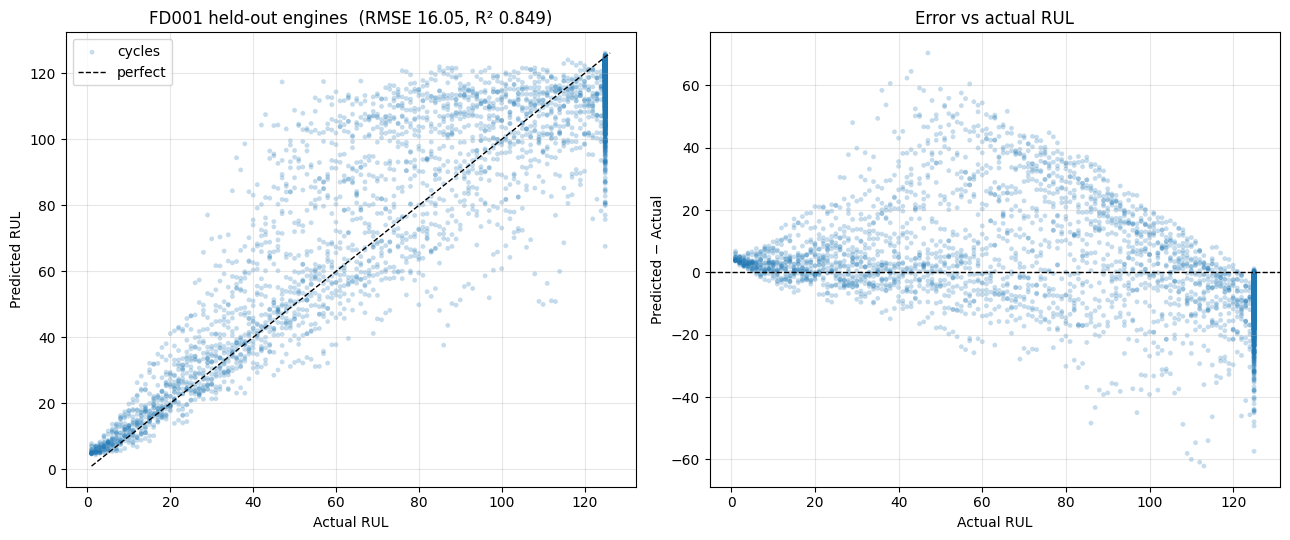

Top 12 features by gain:
      feature  importance
 s4_rollmean5    0.472949
s11_rollmean5    0.219375
 s9_rollmean5    0.078461
 s7_rollmean5    0.040884
           s9    0.023015
s14_rollmean5    0.016810
s12_rollmean5    0.014368
          s11    0.011696
          s13    0.008297
          s15    0.008276
          s12    0.008003
          s14    0.006947

top 3 features account for 77.1% of total importance


In [ ]:

# ============================= 11. EVALUATE =============================
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# --- left: actual vs predicted on held-out engines
ax = axes[0]
ax.scatter(y_val, val_pred, alpha=0.25, s=12, edgecolors="none", label="cycles")
lo = float(min(y_val.min(), val_pred.min()))
hi = float(max(y_val.max(), val_pred.max()))
ax.plot([lo, hi], [lo, hi], "--", c="k", lw=1, label="perfect")
ax.set_xlabel("Actual RUL")
ax.set_ylabel("Predicted RUL")
ax.set_title(f"FD001 held-out engines  (RMSE {rmse:.2f}, R² {r2:.3f})")
ax.grid(alpha=0.3)
ax.legend()

# --- right: error against actual RUL
ax = axes[1]
errors = val_pred - y_val.values
ax.scatter(y_val, errors, alpha=0.25, s=12, edgecolors="none")
ax.axhline(0, ls="--", c="k", lw=1)
ax.set_xlabel("Actual RUL")
ax.set_ylabel("Predicted − Actual")
ax.set_title("Error vs actual RUL")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
plt.close(fig)

importance = (
    pd.DataFrame({"feature": FEATURES, "importance": model.feature_importances_})
    .sort_values("importance", ascending=False)
)
print("Top 12 features by gain:")
print(importance.head(12).to_string(index=False))
print(f"\ntop 3 features account for "
      f"{100 * importance['importance'].head(3).sum() / importance['importance'].sum():.1f}% of total importance")

FD001 official test set - pointwise (final cycle)
----------------------------------------------------
  RMSE               :   18.365
  MAE                :   13.197
  asymmetric score   :   0.4636   (higher is better, max 1.0)
FD001 official test set - last-30-cycle mean
----------------------------------------------------
  RMSE               :   22.879
  MAE                :   17.049
  asymmetric score   :   0.3932   (higher is better, max 1.0)


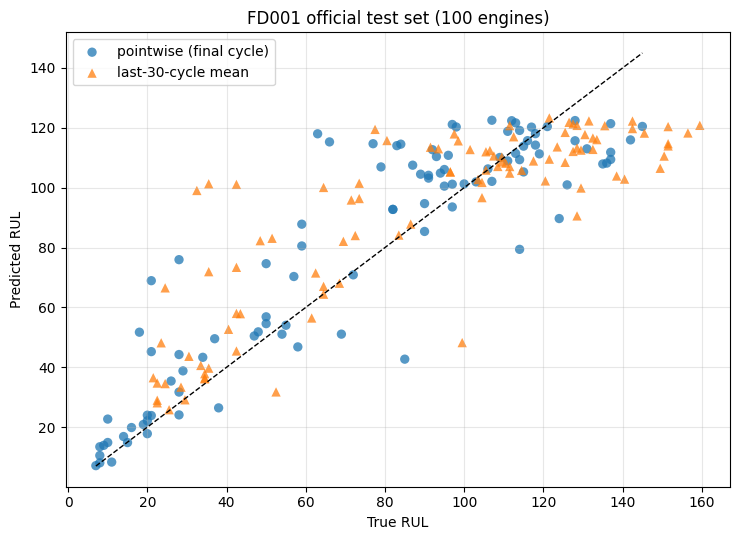

In [ ]:

# --------------- 11b. OFFICIAL TEST-SET SCORING (asymmetric score) ---------------
# The graded benchmark: label each test engine's final cycle with its true RUL
# from RUL_FD001.txt, predict there, and score.
#
# NOTE ON INTERPRETATION: pointwise scoring of a single cycle per engine is the
# harsh C-MAPSS setup and RMSE in the high teens is normal and expected. The
# last-window mean is reported alongside it because averaging over the final
# 30 cycles is what an operator actually experiences.
TEST_SENSORS = [c for c in test_fe.columns if c not in IDENTIFIERS]
if TEST_SENSORS != FEATURES:
    raise ValueError("feature order differs between train and test")


def asymmetric_score(actual, predicted):
    '''NASA's score: late predictions are penalised more than early ones.'''
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    diff = predicted - actual
    return float(np.mean(np.where(diff < 0, np.exp(-(-diff) / 13.0), np.exp(-diff / 10.0))))


test = test_fe.copy()
true_rul = raw["FD001"]["rul"]["RUL"].to_numpy()
test["unit"] = test["unit"].astype(int)

# last row of every test engine, ordered by engine id (RUL_FD00x is in that order)
last_idx = test.groupby("unit")["cycle"].idxmax()
final = test.loc[np.sort(last_idx)].copy()

if len(final) != len(true_rul):
    raise ValueError(f"got {len(final)} final cycles but {len(true_rul)} RUL labels")

X_final_s = scaler.transform(final[FEATURES])
final["RUL_pred"] = np.clip(model.predict(X_final_s), 1, RUL_CAP)

pred_by_engine = final.set_index("unit")["RUL_pred"]
window = 30

# Ground truth is only given for the LAST cycle of each test engine. Reconstruct
# the true RUL for earlier cycles in the window: an engine at cycle c, whose
# final observed cycle is f and whose remaining life is R, had R + (f - c)
# cycles left. Averaging predictions over the window is only meaningful when the
# targets move with it -- comparing a window mean against a single final-cycle
# RUL would penalise the model for a target it was never shown.
final_cycle_by_unit = final.set_index("unit")["cycle"]

rows = []
for unit, group in test.groupby("unit"):
    truth = float(true_rul[unit - 1])
    f = int(final_cycle_by_unit.loc[unit])

    window_rows = group[group["cycle"] > f - window].sort_values("cycle")
    if window_rows.empty:
        window_rows = group.nlargest(1, "cycle")

    win_pred = np.clip(model.predict(scaler.transform(window_rows[FEATURES])), 1, RUL_CAP)
    win_true = truth + (f - window_rows["cycle"].to_numpy())

    rows.append({
        "unit": int(unit),
        "true_RUL": truth,
        "pred_RUL_final": float(pred_by_engine.loc[unit]),
        f"true_RUL_last{window}_mean": float(win_true.mean()),
        f"pred_RUL_last{window}_mean": float(win_pred.mean()),
        f"n_window_cycles": int(len(window_rows)),
    })

results = pd.DataFrame(rows)

for label, pcol, acol in (
    ("pointwise (final cycle)", "pred_RUL_final", "true_RUL"),
    (f"last-{window}-cycle mean", f"pred_RUL_last{window}_mean", f"true_RUL_last{window}_mean"),
):
    p = results[pcol].to_numpy()
    a = results[acol].to_numpy()
    print(f"FD001 official test set - {label}")
    print("-" * 52)
    print(f"  RMSE               : {np.sqrt(mean_squared_error(a, p)):8.3f}")
    print(f"  MAE                : {mean_absolute_error(a, p):8.3f}")
    print(f"  asymmetric score   : {asymmetric_score(a, p):8.4f}   (higher is better, max 1.0)")

plt.figure(figsize=(7.5, 5.5))
plt.scatter(results["true_RUL"], results["pred_RUL_final"], s=45, alpha=0.75,
            edgecolors="none", label="pointwise (final cycle)")
plt.scatter(results[f"true_RUL_last{window}_mean"], results[f"pred_RUL_last{window}_mean"],
            s=45, alpha=0.75, marker="^", edgecolors="none", label=f"last-{window}-cycle mean")
lo = float(min(results["true_RUL"].min(), results["pred_RUL_final"].min()))
hi = float(max(results["true_RUL"].max(), results["pred_RUL_final"].max()))
plt.plot([lo, hi], [lo, hi], "--", c="k", lw=1)
plt.xlabel("True RUL")
plt.ylabel("Predicted RUL")
plt.title(f"FD001 official test set ({len(results)} engines)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
plt.close("all")

In [ ]:

# =========================== 12. ARTIFACTS ===========================
model_path = MODEL_DIR / "xgboost_fd001_rul.json"
metrics_path = MODEL_DIR / "metrics_fd001.json"
feature_path = MODEL_DIR / "feature_contract.json"

model.save_model(str(model_path))

# The backend must bundle the scaler and the exact feature order, otherwise the
# ONNX/XGBoost artifact alone cannot reproduce these predictions.
with open(MODEL_DIR / "scaler_fd001.pkl", "wb") as fh:
    pickle.dump({"scaler": scaler, "features": FEATURES}, fh)

test_metrics = {}
for label, pcol, acol in (
    ("pointwise_final_cycle", "pred_RUL_final", "true_RUL"),
    (f"last_{window}_cycle_mean", f"pred_RUL_last{window}_mean", f"true_RUL_last{window}_mean"),
):
    p = results[pcol].to_numpy()
    a = results[acol].to_numpy()
    test_metrics[label] = {
        "rmse": float(np.sqrt(mean_squared_error(a, p))),
        "mae": float(mean_absolute_error(a, p)),
        "asymmetric_score": asymmetric_score(a, p),
    }

metrics = {
    "subset": "FD001",
    "n_features": len(FEATURES),
    "rul_cap": RUL_CAP,
    "roll_window": ROLL_WINDOW,
    "roll_sensors": ROLL_SENSORS,
    "random_state": RANDOM_STATE,
    "best_iteration": n_trees,
    "grouped_validation": {"mae": float(mae), "rmse": rmse, "r2": float(r2)},
    "official_test": test_metrics,
}
metrics_path.write_text(json.dumps(metrics, indent=2))

# Contract for the FastAPI ML service (item 45 of the backend spec).
feature_path.write_text(json.dumps({
    "model_file": model_path.name,
    "sensor_order": KEEP_SENSORS,
    "feature_order": FEATURES,
    "operating_settings": ["op1", "op2", "op3"],
    "excluded": ["unit", "cycle", "RUL"],
    "roll_window": ROLL_WINDOW,
    "rul_cap": RUL_CAP,
    "requires_scaler": True,
    "scaler_file": "scaler_fd001.pkl",
}, indent=2))

print("Validation metrics:")
print(json.dumps(metrics["grouped_validation"], indent=2))
print("\nOfficial test metrics:")
print(json.dumps(metrics["official_test"], indent=2))

print(f"\nSaved to {MODEL_DIR}:")
for path in sorted(MODEL_DIR.glob("*")):
    print(f"  {path.name:<28} {path.stat().st_size / 1e3:8.1f} KB")
print(f"\nAll artifacts are on Google Drive at {ROOT}")

In [ ]:
# ===================== 14. REGIME DETECTION (multi-regime) =====================
# FD001 and FD003 fly ONE operating condition; FD002 and FD004 fly SIX. A sensor
# reading only means something relative to the condition it was taken in -- 2400 degB
# at cruise and 2400 degB at idle are different states of health. Pooling the subsets
# without conditioning on the regime teaches the model the regimes instead of the
# degradation.
#
# WHY THE REGIME COUNT IS FIXED RATHER THAN COUNTED
# The obvious move is "the distinct (op1, op2, op3) rows are the regimes". It is
# wrong: the settings columns carry small incidental variation even in the
# single-condition subsets, so counting distinct combinations can manufacture four or
# sixteen "regimes" for FD001 -- which would change its feature count and break
# parity with the serving model. The number of operating conditions is a documented
# property of each subset, so it is stated here rather than inferred from the data.
#
# Centroids come from a SEEDED k-means over the distinct combinations: deterministic,
# reproducible, and stored with the model so inference assigns regimes identically.
from sklearn.cluster import KMeans

MULTI_SUBSETS = SUBSETS                 # FD001, FD002, FD003, FD004
REGIME_SETTINGS = ["op1", "op2", "op3"]
# Operating conditions per subset, as published with the C-MAPSS data set.
CONDITIONS = {"FD001": 1, "FD002": 6, "FD003": 1, "FD004": 6}

regime_centroids = {}    # subset -> ndarray (n_regimes, 3)
REGIME_OFFSETS = {}      # subset -> global id offset, so pooled regime ids never collide

_offset = 0
for fd in MULTI_SUBSETS:
    combos = raw[fd]["train"][REGIME_SETTINGS].drop_duplicates().to_numpy(dtype=float)
    combos = combos[np.lexsort(combos.T[::-1])]          # deterministic input order
    n_regimes = min(CONDITIONS.get(fd, len(combos)), len(combos))
    if n_regimes <= 1:
        centroids = combos.mean(axis=0, keepdims=True)   # single condition: its mean
    else:
        centroids = KMeans(n_clusters=n_regimes, n_init=10,
                           random_state=RANDOM_STATE).fit(combos).cluster_centers_
    regime_centroids[fd] = centroids
    REGIME_OFFSETS[fd] = _offset
    _offset += len(centroids)


def assign_regime(frame, fd):
    '''Nearest-centroid regime id per row, on the three settings.'''
    settings = frame[REGIME_SETTINGS].to_numpy(dtype=float)
    centroids = regime_centroids[fd]
    distances = ((settings[:, None, :] - centroids[None, :, :]) ** 2).sum(axis=2)
    return distances.argmin(axis=1).astype(int)


for fd in MULTI_SUBSETS:
    n_expected = CONDITIONS.get(fd)
    train_r = assign_regime(raw[fd]["train"], fd)
    test_r = assign_regime(raw[fd]["test"], fd)
    counts = np.bincount(train_r, minlength=len(regime_centroids[fd]))
    n_combos = len(raw[fd]["train"][REGIME_SETTINGS].drop_duplicates())
    print(f"{fd}: {len(regime_centroids[fd])} regime(s) "
          f"(published: {n_expected}) from {n_combos} distinct setting combinations | "
          f"rows per regime {counts.tolist()}")
    if n_expected is not None and len(regime_centroids[fd]) != n_expected:
        print(f"  WARNING: expected {n_expected} regimes for {fd}")

log(f"regimes per subset: { {fd: len(regime_centroids[fd]) for fd in MULTI_SUBSETS} }")


In [ ]:
# ===================== 15. PER-REGIME BASELINE STATS =====================
# Each engine is taken to be healthy for its first HEALTHY_CYCLES cycles -- the
# convention the backend contract already uses (docs/08 §4). For every
# (regime, sensor) pair we record the median and MAD of those healthy readings.
#
# MAD, not standard deviation: the healthy population per regime is small, and one
# odd cycle would inflate a std and shrink every downstream z-score towards zero.
#
# This is the piece that makes the regimes comparable. A sensor is compared against
# the healthy baseline of the condition it was actually measured in.

HEALTHY_CYCLES = 20
MIN_BASELINE_ROWS = 30

# PER-SUBSET SENSOR SELECTION (previously: one union list for all four subsets).
#
# The union rule drops a sensor unless it is non-constant in EVERY subset, so FD002 and
# FD004 -- where s1, s5, s10, s16, s18 and s19 genuinely vary -- were modelled on the
# same 15 sensors as FD001, discarding 6 columns that carry information for them.
#
# The old justification was that those sensors "vary by regime, not degradation", so
# they look useless. That argument only holds for RAW sensors. This pipeline z-scores
# every sensor against its own regime's healthy baseline (cell 17), which removes the
# regime component by construction -- what survives the z-score is exactly the
# within-regime degradation. Post-normalisation these sensors are informative for
# FD002/FD004 and merely constant for FD001/FD003, which is why they are droppable per
# subset but were never droppable from a pooled frame.
#
# FD001/FD003 keep their current 15 sensors, so the 29-feature serving contract from
# cell 8 is untouched. Only the multi-regime candidates gain features.
#
# Set SENSOR_SELECTION = "union" to restore the old behaviour for an A/B comparison.
SENSOR_SELECTION = "per_subset"       # "per_subset" | "union"

ALL_SENSORS = [c for c in raw["FD001"]["train"].columns if c.startswith("s")]
UNION_SENSORS = [s for s in ALL_SENSORS
                 if all(raw[fd]["train"][s].nunique() > 1 for fd in MULTI_SUBSETS)]
SUBSET_SENSORS = {fd: [s for s in ALL_SENSORS if raw[fd]["train"][s].nunique() > 1]
                  for fd in MULTI_SUBSETS}
Z_SENSORS_BY_SUBSET = (
    {fd: list(SUBSET_SENSORS[fd]) for fd in MULTI_SUBSETS}
    if SENSOR_SELECTION == "per_subset"
    else {fd: list(UNION_SENSORS) for fd in MULTI_SUBSETS}
)
# Retained for the single-subset reporting paths; prefer Z_SENSORS_BY_SUBSET whenever
# the subset is known, which is everywhere in Phase 2.
Z_SENSORS = UNION_SENSORS

for _fd in MULTI_SUBSETS:
    _sel = Z_SENSORS_BY_SUBSET[_fd]
    _extra = [s for s in _sel if s not in UNION_SENSORS]
    print(f"{_fd}: {len(_sel)} sensors selected"
          + (f" ({len(_extra)} beyond the union: {', '.join(_extra)})" if _extra else "")
          + f" | conditions {CONDITIONS.get(_fd)}")
print(f"union rule (previous behaviour) gave every subset {len(UNION_SENSORS)}: "
      f"{UNION_SENSORS}")

regime_baselines = {}    # subset -> {regime_id: {sensor: {median, mad, n, source}}}

for fd in MULTI_SUBSETS:
    frame = raw[fd]["train"]
    regime = assign_regime(frame, fd)
    healthy = frame["cycle"].to_numpy() <= HEALTHY_CYCLES
    per_regime = {}

    for rid in range(len(regime_centroids[fd])):
        in_regime = (regime == rid) & healthy
        stats = {}
        for sensor in Z_SENSORS_BY_SUBSET[fd]:
            values = frame.loc[in_regime, sensor].to_numpy(dtype=float)
            source = "regime"
            if values.size < MIN_BASELINE_ROWS:
                # too few healthy cycles in this regime: fall back to every healthy
                # cycle of the subset rather than dividing by an unstable MAD
                values = frame.loc[healthy, sensor].to_numpy(dtype=float)
                source = "subset-wide fallback"
            med = float(np.median(values))
            mad = float(np.median(np.abs(values - med)))
            stats[sensor] = {"median": round(med, 6), "mad": round(mad, 6),
                             "n": int(values.size), "source": source}
        per_regime[rid] = stats

    regime_baselines[fd] = per_regime
    sparse = sum(1 for st in per_regime.values() for v in st.values() if v["source"] != "regime")
    log(f"{fd}: baselines for {len(per_regime)} regime(s) x "
        f"{len(Z_SENSORS_BY_SUBSET[fd])} sensors"
        + (f" | {sparse} fell back to the subset-wide healthy pool" if sparse else ""))


In [ ]:
# ============ 16. MODELING FRAMES (namespaced engine ids + capped target) ============
# UNIT IDS ARE REUSED ACROSS SUBSETS. Every file numbers its engines 1..N because each
# is an independent fleet, so FD002's engine 7 and FD004's engine 7 are different
# machines. Pooled as-is they would land in the same cross-validation fold and leak.
# Every id is namespaced "FDxxx#unit" BEFORE any split -- that is what makes the
# grouped folds in cell 18 sound.
#
# The target reuses add_rul() from cell 6: (max_cycle - cycle + 1), capped at 125.

def build_frame(fd, split):
    '''One subset/split as a modeling frame: namespaced id, regime, ordered by cycle.'''
    frame = raw[fd][split].copy()
    frame["unit"] = frame["unit"].astype(int)
    frame["cycle"] = frame["cycle"].astype(int)
    frame["unit_key"] = f"{fd}#" + frame["unit"].astype(str)
    frame["regime"] = assign_regime(frame, fd)
    return frame.sort_values(["unit_key", "cycle"]).reset_index(drop=True)


frames = {fd: {"train": build_frame(fd, "train"), "test": build_frame(fd, "test")}
          for fd in MULTI_SUBSETS}

for fd in MULTI_SUBSETS:
    frames[fd]["train"]["RUL"] = add_rul(frames[fd]["train"])
    tr = frames[fd]["train"]
    print(f"{fd}: train {tr.shape[0]:>6} rows / {tr['unit_key'].nunique():>3} engines | "
          f"RUL {tr['RUL'].min():.0f}-{tr['RUL'].max():.0f} mean {tr['RUL'].mean():5.1f}"
          f" | test {frames[fd]['test'].shape[0]:>6} rows / "
          f"{frames[fd]['test']['unit_key'].nunique():>3} engines")

all_keys = [k for fd in MULTI_SUBSETS for k in frames[fd]["train"]["unit_key"].unique()]
if len(all_keys) != len(set(all_keys)):
    raise RuntimeError("engine id collision across subsets -- namespacing failed")
print(f"{len(all_keys)} distinct engine ids across {len(MULTI_SUBSETS)} subsets")


In [ ]:
# ================= 17. MULTI-REGIME FEATURES (per-regime z + rolling) =================
# Two stages:
#   1. every sensor becomes a z-score against ITS OWN regime's healthy baseline, so
#      the same number means "healthy for this condition" everywhere;
#   2. a rolling mean/std over a ROLL_WINDOW window inside each engine captures the
#      trend, which is where nearly all the predictive signal lives (see cell 11:
#      s4_rollmean5 carries 0.47 of the gain while raw s4 carries 0.02).
#
# FOR SINGLE-REGIME SUBSETS STAGE 1 IS A NO-OP. With one regime it is a per-column
# affine transform, and gradient boosting is invariant to that. FD001 therefore keeps
# exactly the 29 features of cell 8 -- adding this machinery does not change what the
# serving model means, it only makes FD002/FD004 poolable.

EPS_MAD = 1e-6
MULTI_ROLL_SENSORS = ROLL_SENSORS

# Z_SENSORS_BY_SUBSET is resolved in cell 15, where it also drives the baselines. It is
# per subset, so the feature set is a property of the subset being built.


def build_features(frame, fd):
    '''Deterministic feature matrix for one subset. Column order is built here and
    asserted downstream -- it is never inferred from the data.'''
    stats = regime_baselines[fd]
    regimes = frame["regime"].to_numpy()
    sensors = Z_SENSORS_BY_SUBSET[fd]

    z = {}
    for sensor in sensors:
        med = np.array([stats[r][sensor]["median"] for r in regimes])
        mad = np.array([max(stats[r][sensor]["mad"], EPS_MAD) for r in regimes])
        z[sensor] = (frame[sensor].to_numpy(dtype=float) - med) / mad
    zdf = pd.DataFrame(z, index=frame.index)
    grouped = zdf.groupby(frame["unit_key"], sort=False)

    cols = {sensor: zdf[sensor].to_numpy() for sensor in sensors}
    for sensor in MULTI_ROLL_SENSORS:
        if sensor not in zdf.columns:
            continue
        roll = grouped[sensor].rolling(window=ROLL_WINDOW, min_periods=1)
        cols[f"{sensor}_rollmean{ROLL_WINDOW}"] = (
            roll.mean().reset_index(level=0, drop=True).to_numpy())
        cols[f"{sensor}_rollstd{ROLL_WINDOW}"] = (
            roll.std(ddof=0).reset_index(level=0, drop=True).to_numpy())

    # Settings stay raw: they identify the condition, which stage 1 deliberately
    # removed from the sensors. regime_global is namespaced by subset so a regime 0 in
    # FD001 can never be confused with a regime 0 in FD002 once frames are pooled.
    cols["op1"] = frame["op1"].to_numpy(dtype=float)
    cols["op2"] = frame["op2"].to_numpy(dtype=float)
    cols["regime_global"] = regimes.astype(float) + REGIME_OFFSETS[fd]

    names = ["op1", "op2"] + sensors + [c for c in cols if "_roll" in c] + ["regime_global"]
    matrix = pd.DataFrame({c: cols[c] for c in names}, index=frame.index)
    if not np.isfinite(matrix.to_numpy()).all():
        raise ValueError(f"{fd}: non-finite value in the feature matrix")
    return names, matrix


def pooled_frame(tags):
    '''Concatenate the requested subsets. Row order matches pooled_matrix exactly.'''
    parts = [frames[fd]["train"] for fd in tags]
    return pd.concat(parts, ignore_index=True) if len(parts) > 1 else parts[0].copy()


def pooled_matrix(tags, split="train"):
    '''Per-subset feature build, then concatenate.

    Baselines are per subset AND per regime, so the features must be built while each
    subset is still separate -- normalising a pooled frame would compare an FD002
    cruise reading against an FD001 sea-level baseline.
    '''
    mats = []
    for fd in tags:
        _, matrix = build_features(frames[fd][split], fd)
        mats.append(matrix)
    if len(mats) == 1:
        return mats[0]

    # Subsets now contribute different sensor sets, so align on the union of columns.
    # A sensor that is constant within a subset has mad == 0, so its z-score is exactly
    # 0.0 on every row of that subset -- filling 0 therefore reproduces what the subset
    # would have produced itself, and drop_constant_columns then removes the all-zero
    # column unless some other subset supplies real variation in it.
    union = list(dict.fromkeys(c for m in mats for c in m.columns))
    return pd.concat([m.reindex(columns=union, fill_value=0.0) for m in mats],
                     ignore_index=True)


def align_to(matrix, other):
    '''Line a single-subset feature frame up with a pooled training matrix.

    Needed wherever one subset's rows meet a model fitted on several subsets (the exam
    CV in cell 25, the official test scoring in cell 27). Columns the subset does not
    contribute are zero-filled for the same reason as in pooled_matrix.
    '''
    return other.reindex(columns=matrix.columns, fill_value=0.0)


PROTECTED_COLUMNS = ["op1", "op2"]


def drop_constant_columns(matrix):
    '''Drop columns that never vary -- no split can ever be placed on them.

    The settings columns are protected deliberately. They are constant in some
    single-regime subsets, and Phase 1 (cell 8) fed them to XGBoost regardless, so
    protecting them is what keeps a single-regime Phase 2 model on exactly the same
    29-feature contract as the serving model. XGBoost simply never splits on a
    constant column, so keeping them changes no prediction -- only the contract.
    The one column this actually removes is regime_global when there is one regime.'''
    keep = [c for c in matrix.columns
            if c in PROTECTED_COLUMNS or matrix[c].nunique() > 1]
    return matrix[keep], [c for c in matrix.columns if c not in keep]


_names, _m = build_features(frames["FD001"]["train"], "FD001")
_m, _dropped = drop_constant_columns(_m)
print(f"FD001 features: {len(_m.columns)} ({len(_dropped)} constant dropped: {_dropped})")
if len(_m.columns) != len(FEATURES):
    print(f"  NOTE: differs from the cell 8 serving feature count ({len(FEATURES)})")
else:
    print(f"  matches the cell 8 serving feature set exactly")


In [ ]:
# ==================== 18. GROUPED K-FOLD HARNESS ==================== 
# A single 80/20 split is too noisy to choose between models: with ~20 engines per
# split, the split noise is larger than the differences being measured. Every
# candidate is therefore scored with the SAME 5-fold GroupKFold, grouped by namespaced
# engine id, and reported as mean +/- std across folds.
#
# N_BOOST_CV is lower than the serving N_BOOST: 5 folds x 6 candidates must fit in a
# per-cell time budget. Early stopping keeps the effective model size honest anyway.
from sklearn.model_selection import GroupKFold

CV_FOLDS = 5
N_BOOST_CV = 300
EARLY_STOP_CV = 40


def make_model(n_boost=N_BOOST_CV, early=EARLY_STOP_CV):
    return XGBRegressor(
        objective="reg:squarederror",
        n_estimators=n_boost,
        learning_rate=0.05,
        max_depth=6,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        tree_method="hist",
        early_stopping_rounds=early,
        verbosity=0,
    )


def cross_validate(tags, folds=CV_FOLDS):
    '''Mean +/- std RMSE/MAE/R2 over grouped folds. Leakage is asserted, not assumed.'''
    frame = pooled_frame(tags)
    matrix, dropped = drop_constant_columns(pooled_matrix(tags))
    y = frame["RUL"].to_numpy()
    groups = frame["unit_key"].to_numpy()

    scores = {"rmse": [], "mae": [], "r2": [], "rounds": []}
    for fold, (tr, va) in enumerate(GroupKFold(n_splits=folds).split(matrix, y, groups), 1):
        overlap = set(groups[tr]) & set(groups[va])
        if overlap:
            raise RuntimeError(f"engine leakage in fold {fold}: {len(overlap)} shared ids")
        model = make_model()
        model.fit(matrix.iloc[tr], y[tr], eval_set=[(matrix.iloc[va], y[va])], verbose=False)
        pred = model.predict(matrix.iloc[va])

        rmse = float(np.sqrt(((pred - y[va]) ** 2).mean()))
        mae = float(np.abs(pred - y[va]).mean())
        r2 = float(1 - ((pred - y[va]) ** 2).sum() / ((y[va] - y[va].mean()) ** 2).sum())
        scores["rmse"].append(rmse)
        scores["mae"].append(mae)
        scores["r2"].append(r2)
        scores["rounds"].append(int(model.best_iteration) + 1)
        log(f"  fold {fold}/{folds}: {len(tr):>6} rows / {len(set(groups[tr])):>3} engines "
            f"-> RMSE {rmse:6.3f}  MAE {mae:6.3f}  R2 {r2:6.3f}  "
            f"({scores['rounds'][-1]} rounds)")

    return {
        "subsets": list(tags),
        "engines": int(pd.Series(groups).nunique()),
        "rows": int(matrix.shape[0]),
        "n_features": int(matrix.shape[1]),
        "constant_dropped": dropped,
        "rmse_mean": float(np.mean(scores["rmse"])), "rmse_std": float(np.std(scores["rmse"])),
        "mae_mean": float(np.mean(scores["mae"])), "mae_std": float(np.std(scores["mae"])),
        "r2_mean": float(np.mean(scores["r2"])), "r2_std": float(np.std(scores["r2"])),
        "rounds_mean": float(np.mean(scores["rounds"])),
        "fold_rmse": [round(v, 3) for v in scores["rmse"]],
    }


CANDIDATES = {}


def run_candidate(tag, tags):
    '''Cross-validate one candidate and remember the result for the report.'''
    log(f"=== candidate {tag}: {' + '.join(tags)} ===")
    t0 = time.time()
    result = cross_validate(tags)
    result["tag"] = tag
    result["seconds"] = round(time.time() - t0, 1)
    CANDIDATES[tag] = result
    print(f"{tag}: RMSE {result['rmse_mean']:.3f} +/- {result['rmse_std']:.3f} | "
          f"MAE {result['mae_mean']:.3f} | R2 {result['r2_mean']:.3f} | "
          f"{result['n_features']} features | {result['seconds']}s")
    return result


# The candidate roster, defined ONCE. Cells 26 and 26b both iterate it, so a candidate
# can never be persisted by one cell and refit by the other.
CANDIDATE_SETS = (
    ("FD001", ["FD001"]),
    ("FD003", ["FD003"]),
    ("FD001+FD003", ["FD001", "FD003"]),
    ("FD002", ["FD002"]),
    ("FD004", ["FD004"]),
    ("ALL", MULTI_SUBSETS),
)

# SELECTION RULE, fixed before any test number is looked at.
# The official C-MAPSS test set is NEVER a selection input. Model configuration,
# boosting rounds and the final ranking come from engine-level cross-validation on the
# training data alone. Test numbers appear only in the post-selection sanity check in
# cell 26b, and they must not feed back into any choice.
SELECTION_METRIC = "cv_rmse_mean"


In [ ]:
# ---- candidate: FD001 ----
# The Phase 1 serving model, re-scored under the new protocol. The mean of 5 grouped folds is the honest reference number -- it should land in the same band as the single-split RMSE of 16.05 reported in cell 10.
run_candidate("FD001", ['FD001'])


In [ ]:
# ---- candidate: FD003 ----
# Single regime, two fault modes (HPC + fan). Trained alone to see whether the extra fault mode costs accuracy relative to FD001's single fault mode.
run_candidate("FD003", ['FD003'])


In [ ]:
# ---- candidate: FD001+FD003 ----
# Both single-regime, so they pool with no regime handling at all -- 200 engines instead of 100. This is the cheapest possible accuracy win, if it is one.
run_candidate("FD001+FD003", ['FD001', 'FD003'])


In [ ]:
# ---- candidate: FD002 ----
# Six operating conditions, one fault mode. Trained alone WITH the per-regime z-scoring of cell 17; without it this subset is unusable.
run_candidate("FD002", ['FD002'])


In [ ]:
# ---- candidate: FD004 ----
# Six operating conditions and two fault modes -- the hardest of the four, and the closest match to a real multi-condition fleet.
run_candidate("FD004", ['FD004'])


In [ ]:
# ---- candidate: ALL ----
# Everything pooled into one model behind the regime column. The most training data available, and the model the backend would load if regime support is switched on.
run_candidate("ALL", ['FD001', 'FD002', 'FD003', 'FD004'])


In [ ]:
# ============ 18b. EXAM-STYLE CV -- the metric that matches the official test ============
# WHY THIS CELL EXISTS
# Row-level CV and the official test are not measuring the same thing. CV scores EVERY
# row, including the easy early-life rows that sit on the 125 plateau. The official test
# scores ONE row per engine: the last cycle of an engine that was cut off before it
# failed. That is the hardest possible question, and it is why FD002/FD004 look far worse
# on the test (28-30) than under row-level CV (17-18).
#
# v1 OF THIS CELL SAMPLED THE CUT UNIFORMLY OVER THE ENGINE'S CYCLES, and it was still
# optimistic. On a 250-cycle FD002 engine, cutting at cycle 31 leaves 219 cycles of life,
# which the 125 cap flattens into an easy "125" target -- so a large share of the scored
# rows were plateau questions the real test never asks. Measured result: exam CV 20.3
# against a 29.96 official test score for FD004. The metric was flattering the model.
#
# THIS VERSION MATCHES THE OFFICIAL DISTRIBUTION. Each held-out engine is assigned a
# target RUL drawn from that subset's actual RUL_FD00x.txt, then cut exactly that many
# cycles early. Every scored row is now the question NASA asks -- "the engine stops here,
# how long has it got?" -- so exam CV and the official test differ only in which engines
# were used to fit the model, not in how hard the question is.
#
# THE OFFICIAL TEST IS NOW SCORED HERE TOO, with the same fold models. All three columns
# below are therefore comparable. v1 compared exam CV against row-level CV only and so
# printed "consistent" for FD002 while a 7-cycle exam-to-test gap sat unread in the very
# next column.
#
# CRITICAL: features are built on the truncated history. Building them on the full engine
# and then scoring the last row would let the rolling window see the future and would
# reproduce the flattering CV number.
#
# ON THE 125 CAP: targets are the RAW RUL_FD00x values, which reach ~145, while
# predictions are clipped to RUL_CAP. A target above 125 therefore contributes at least
# (target - 125) of unavoidable error. That is a property of the official scoring too,
# not an artefact of this harness, and it cannot be removed without abandoning the
# piecewise-linear target from cell 6.

EXAM_MIN_HISTORY = 31        # enough cycles for a 5-window plus some degradation signal


def _truncate(frame, engine, cut):
    # Rows of one engine up to and including `cut` cycles, as a fresh frame.
    # Feature construction must see only these rows: anything later is future data.
    part = frame[frame["unit_key"] == engine]
    return part[part["cycle"] <= cut].reset_index(drop=True)


def _official_rows(fd):
    '''Last observed cycle of every official test engine, plus its true RUL.'''
    _, matrix = build_features(frames[fd]["test"], fd)
    last = frames[fd]["test"].groupby("unit_key")["cycle"].idxmax()
    final = frames[fd]["test"].loc[last].sort_values("unit")
    rows = matrix.loc[last].loc[final.index]
    labels = raw[fd]["rul"]["RUL"].to_numpy(dtype=float)
    if len(final) != len(labels):
        raise ValueError(f"{fd}: {len(final)} final cycles vs {len(labels)} RUL labels")
    return final, rows, labels


def exam_style_cv(tags, folds=CV_FOLDS, seed=RANDOM_STATE):
    '''Grouped CV in which each held-out engine is scored ONCE, at a truncation drawn
    from the official RUL distribution. The same fold models also score the real test.'''
    frame = pooled_frame(tags)
    matrix, dropped = drop_constant_columns(pooled_matrix(tags))
    y = frame["RUL"].to_numpy()
    groups = frame["unit_key"].to_numpy()

    # The RUL values the real test asks about, per subset.
    exam_pool = {fd: raw[fd]["rul"]["RUL"].to_numpy(dtype=float) for fd in tags}
    official = {fd: _official_rows(fd) for fd in tags}

    per_fold, per_engine, test_per_fold = [], [], {fd: [] for fd in tags}
    for fold, (tr, va) in enumerate(GroupKFold(n_splits=folds).split(matrix, y, groups), 1):
        model = make_model()
        model.fit(matrix.iloc[tr], y[tr], eval_set=[(matrix.iloc[va], y[va])], verbose=False)
        booster_rounds = int(model.best_iteration) + 1

        # --- the official test, scored with this fold's model (never trained on) ----
        for fd in tags:
            _, rows, labels = official[fd]
            pred = np.clip(model.predict(align_to(matrix, rows)), 1, RUL_CAP)
            test_per_fold[fd].append(float(np.sqrt(mean_squared_error(labels, pred))))

        # --- the same question, asked inside CV at distribution-matched cut points ---
        rng = np.random.default_rng(seed + fold)
        errors = []
        for engine in pd.unique(groups[va]):
            n = int((groups == engine).sum())
            fd = engine.split("#")[0]
            # A target is only answerable if enough history survives the cut.
            feasible = exam_pool[fd][exam_pool[fd] <= n - EXAM_MIN_HISTORY]
            if feasible.size == 0:
                continue
            true = float(rng.choice(feasible))
            cut = n - int(round(true))

            visible = _truncate(frame, engine, cut)
            if len(visible) != cut:
                raise AssertionError(
                    f"{engine}: a cut at cycle {cut} kept {len(visible)} rows -- cycles "
                    f"are not contiguous from 1, so the truncation maths is wrong")
            _, vmat = build_features(visible, fd)
            # .iloc, not []: pandas reads df[[-1]] as a LABEL lookup, and these frames
            # are indexed 0..n-1, so the positional form is required.
            pred = float(np.clip(model.predict(align_to(matrix, vmat).iloc[[-1]])[0],
                                 1, RUL_CAP))
            errors.append(pred - true)
            per_engine.append({"fold": fold, "engine": engine, "cut": cut,
                               "true_rul": true, "pred": round(pred, 2),
                               "error": round(pred - true, 3)})

        if not errors:
            continue
        rmse = float(np.sqrt(np.mean(np.square(errors))))
        per_fold.append(rmse)
        log(f"  fold {fold}/{folds}: {len(errors):>3} engines scored at a matched "
            f"truncation -> RMSE {rmse:6.3f} ({booster_rounds} boosting rounds)")

    if not per_fold:
        raise RuntimeError("no engine long enough to truncate")

    return {
        "subsets": list(tags), "folds": folds,
        "rmse_mean": float(np.mean(per_fold)), "rmse_std": float(np.std(per_fold)),
        "fold_rmse": [round(v, 3) for v in per_fold],
        "engines_scored": len(per_engine),
        "official_test_rmse": {fd: float(np.mean(v))
                               for fd, v in test_per_fold.items() if v},
        "official_test_folds": {fd: [round(x, 3) for x in v]
                                for fd, v in test_per_fold.items() if v},
        "per_engine": per_engine,
    }


EXAM_CANDIDATES = (("FD001", ["FD001"]), ("FD004", ["FD004"]), ("FD002", ["FD002"]))
exam_results = {}

for _tag, _tags in EXAM_CANDIDATES:
    log(f"=== exam-style CV: {_tag} ===")
    _t0 = time.time()
    exam_results[_tag] = exam_style_cv(_tags)
    exam_results[_tag]["seconds"] = round(time.time() - _t0, 1)
    r = exam_results[_tag]
    _t = " | ".join(f"{fd} {v:.2f}" for fd, v in r["official_test_rmse"].items())
    print(f"{_tag}: exam-style RMSE {r['rmse_mean']:.3f} +/- {r['rmse_std']:.3f} "
          f"over {r['engines_scored']} truncated engines | official test {_t} "
          f"[{r['seconds']}s]")

print()
print("=" * 86)
print(f"{'subset':<8} {'row-level CV':>13} {'exam-style CV':>15} {'official test':>14} "
      f"{'exam-test':>11}  verdict")
print("-" * 86)
for _tag, _tags in EXAM_CANDIDATES:
    _cv = CANDIDATES[_tag]["rmse_mean"]
    _ex = exam_results[_tag]["rmse_mean"]
    _t = exam_results[_tag]["official_test_rmse"]
    if len(_t) != 1:
        raise ValueError(f"{_tag}: expected a single-subset candidate, got {list(_t)}")
    _test = next(iter(_t.values()))
    _gap = _ex - _test
    if _gap > 5:
        _verdict = "exam CV still optimistic (C) - unmodelled test-time difference"
    elif _gap < -5:
        _verdict = "exam CV pessimistic - truncated history harder than the real test"
    else:
        _verdict = "exam CV reproduces the test"
    print(f"{_tag:<8} {_cv:>13.3f} {_ex:>15.3f} {_test:>14.3f} {_gap:>+11.3f}  {_verdict}")
print("=" * 86)
print("Row-level CV scores every row, so roughly half of them sit on the 125 plateau and")
print("are free. Exam-style CV asks the official question once per engine, at a cut drawn")
print("from the real RUL_FD00x distribution, and the test column is measured with the")
print("same fold models -- so the three columns are directly comparable.")
print()
print("If exam CV and the official test now agree to within fold noise, the harness is")
print("trustworthy and any remaining shortfall is a genuine modelling weakness. If they")
print("still disagree, the harness is the artefact and nothing about the model can be")
print("concluded from either number.")



In [ ]:
# ==================== 25. COMPARISON REPORT ====================
# One table, every candidate, plus the Phase 1 number for reference. Sorted by CV
# RMSE so the winner is visible at a glance, with the spread alongside -- a candidate
# that wins by less than its own std has not really won.

report = pd.DataFrame([
    {
        "candidate": r["tag"],
        "subsets": "+".join(s[-4:] for s in r["subsets"]),
        "engines": r["engines"],
        "rows": r["rows"],
        "features": r["n_features"],
        "RMSE": round(r["rmse_mean"], 3),
        "RMSE_sd": round(r["rmse_std"], 3),
        "MAE": round(r["mae_mean"], 3),
        "R2": round(r["r2_mean"], 4),
        "rounds": int(r["rounds_mean"]),
        "sec": r["seconds"],
    }
    for r in CANDIDATES.values()
]).sort_values("RMSE").reset_index(drop=True)

print(report.to_string(index=False))
_phase1 = {"rmse": rmse, "mae": mae, "r2": r2} if "rmse" in dir() else None
if _phase1:
    print(f"\nreference - Phase 1 FD001 serving model, single 80/20 split: "
          f"RMSE {_phase1['rmse']:.2f}  MAE {_phase1['mae']:.2f}  R2 {_phase1['r2']:.4f}")
    print("(the CV column is a 5-fold mean, so it is not directly comparable to that "
          "single split; both are shown so the drift is visible)")
else:
    print("\n(Phase 1 metrics not in scope -- this cell was run on its own)")

BEST_TAG = report.iloc[0]["candidate"]
FD001_TAG = "FD001"
best_row = CANDIDATES[BEST_TAG]
fd001_row = CANDIDATES[FD001_TAG]
margin = best_row["rmse_mean"] - fd001_row["rmse_mean"]
clear = margin < -fd001_row["rmse_std"]

print("\n" + "=" * 66)
print(f"best candidate : {BEST_TAG}  (RMSE {best_row['rmse_mean']:.3f} "
      f"+/- {best_row['rmse_std']:.3f})")
print(f"FD001 baseline : RMSE {fd001_row['rmse_mean']:.3f} +/- {fd001_row['rmse_std']:.3f}")
print(f"margin         : {margin:+.3f} cycles")
if BEST_TAG == FD001_TAG:
    print("verdict        : the serving FD001 model is already the best option. "
          "Nothing to swap.")
elif clear:
    print(f"verdict        : {BEST_TAG} beats FD001 by more than its own fold spread. "
          "A swap is defensible.")
else:
    print(f"verdict        : {BEST_TAG} is ahead, but by less than the fold spread. "
          "Treat it as a tie and keep the simpler, already-integrated FD001 model "
          "unless Phase 0 integration work is under way anyway.")
print("=" * 66)


In [ ]:
# ==================== 26. PERSIST EVERY CANDIDATE ====================
# Written to models/multi/ -- Phase 1's artifacts in models/ are NOT touched, so the
# serving model and the backend contract stay exactly as they are. Selecting any
# candidate later is a matter of pointing the loader at these files.
#
# Each candidate gets: the booster, its metrics, a feature contract, and the regime
# centroids + baselines it needs at inference time. The contract is the important one:
# inference must rebuild the same columns in the same order, and the regime baselines
# are what make the z-scores reproducible on a live window.

MULTI_DIR = MODEL_DIR / "multi"
MULTI_DIR.mkdir(parents=True, exist_ok=True)


def asymmetric_score(actual, predicted):
    '''Mean of NASA's asymmetric penalty: a late prediction is punished harder.

    Reported because it is bounded in [0, 1] and easy to read, but it is NOT the metric
    published papers quote. Use nasa_score_sum for anything comparable.
    '''
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    diff = predicted - actual
    return float(np.mean(np.where(diff < 0, np.exp(-(-diff) / 13.0), np.exp(-diff / 10.0))))


def nasa_score_sum(actual, predicted):
    '''The standard C-MAPSS score as published: a SUM over engines, lower is better.

    A late prediction (predicted < actual) costs exp(-d/13) - 1; an early one costs
    exp(d/10) - 1, so at equal magnitude lateness is penalised about 30% more. Good
    FD001 models score roughly 450-700 on this; quoting the mean-of-exponentials number
    instead makes results incomparable with the literature.
    '''
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    d = predicted - actual
    return float(np.sum(np.where(d < 0, np.exp(-d / 13.0) - 1.0, np.exp(d / 10.0) - 1.0)))


def fit_and_score(tag, tags):
    '''Final fit at full N_BOOST on an 80/20 engine split, then scored on each
    subset's official truncated test set using its RUL file.'''
    frame = pooled_frame(tags)
    matrix, dropped = drop_constant_columns(pooled_matrix(tags))
    y = frame["RUL"].to_numpy()
    groups = frame["unit_key"].to_numpy()

    splitter = GroupShuffleSplit(n_splits=1, test_size=VAL_FRACTION, random_state=RANDOM_STATE)
    tr, va = next(splitter.split(matrix, y, groups))
    if set(groups[tr]) & set(groups[va]):
        raise RuntimeError("engine leakage in the final 80/20 split")

    model = make_model(n_boost=N_BOOST, early=50)
    model.fit(matrix.iloc[tr], y[tr], eval_set=[(matrix.iloc[va], y[va])], verbose=False)
    val_pred = model.predict(matrix.iloc[va])

    metrics = {
        "candidate": tag,
        "subsets": list(tags),
        "n_features": int(matrix.shape[1]),
        "constant_dropped": dropped,
        "rul_cap": RUL_CAP,
        "roll_window": ROLL_WINDOW,
        "roll_sensors": MULTI_ROLL_SENSORS,
        "z_sensors": {fd: Z_SENSORS_BY_SUBSET[fd] for fd in tags},
        "sensor_selection": SENSOR_SELECTION,
        "healthy_cycles": HEALTHY_CYCLES,
        "best_iteration": int(model.best_iteration) + 1,
        "holdout": {
            "mae": float(mean_absolute_error(y[va], val_pred)),
            "rmse": float(np.sqrt(mean_squared_error(y[va], val_pred))),
            "r2": float(r2_score(y[va], val_pred)),
        },
        "cv": {k: CANDIDATES[tag][k] for k in
               ("rmse_mean", "rmse_std", "mae_mean", "r2_mean", "fold_rmse")},
        "official_test": {},
    }

    for fd in tags:
        _, test_matrix = build_features(frames[fd]["test"], fd)
        # Zero-fill, do not select. A pooled training matrix carries the UNION of
        # every subset's sensors, so a subset that dropped one (FD001 drops s10 as
        # constant; FD003 keeps it) has no such column in its own test matrix and
        # `test_matrix[matrix.columns]` raised KeyError: "['s10'] not in index".
        # This mirrors pooled_matrix, which zero-fills for the same reason: a sensor
        # that is constant within a subset has mad == 0, so its z-score is 0.0 on
        # every row of that subset and filling 0.0 reproduces exactly what the subset
        # would have produced itself. It also pins the column ORDER, which indexing
        # a frame by a list of names does not guarantee.
        test_matrix = test_matrix.reindex(columns=matrix.columns, fill_value=0.0)
        test_frame = frames[fd]["test"]

        # ground truth exists only for each engine's LAST observed cycle
        last = test_frame.groupby("unit_key")["cycle"].idxmax()
        final = test_frame.loc[last].sort_values("unit")
        rows = test_matrix.loc[last].loc[final.index]

        true_rul = raw[fd]["rul"]["RUL"].to_numpy(dtype=float)
        if len(final) != len(true_rul):
            raise ValueError(f"{fd}: {len(final)} final cycles vs {len(true_rul)} RUL labels")

        pred = np.clip(model.predict(rows), 1, RUL_CAP)
        metrics["official_test"][fd] = {
            "engines": int(len(final)),
            "rmse": float(np.sqrt(mean_squared_error(true_rul, pred))),
            "mae": float(mean_absolute_error(true_rul, pred)),
            "asymmetric_score": asymmetric_score(true_rul, pred),
            # the published metric -- the only one comparable with the literature
            "nasa_score": nasa_score_sum(true_rul, pred),
        }

    model.save_model(str(MULTI_DIR / f"xgboost_{tag.lower()}.json"))
    (MULTI_DIR / f"metrics_{tag.lower()}.json").write_text(json.dumps(metrics, indent=2))
    (MULTI_DIR / f"regime_baselines_{tag.lower()}.json").write_text(json.dumps({
        "candidate": tag,
        "settings": REGIME_SETTINGS,
        "healthy_cycles": HEALTHY_CYCLES,
        "eps_mad": EPS_MAD,
        "centroids": {fd: regime_centroids[fd].tolist() for fd in tags},
        "offsets": {fd: REGIME_OFFSETS[fd] for fd in tags},
        "baselines": {fd: regime_baselines[fd] for fd in tags},
    }, indent=2))
    (MULTI_DIR / f"feature_contract_{tag.lower()}.json").write_text(json.dumps({
        "candidate": tag,
        "subsets": list(tags),
        "model_file": f"xgboost_{tag.lower()}.json",
        "feature_order": list(matrix.columns),
        "n_features": int(matrix.shape[1]),
        "sensor_order": {fd: Z_SENSORS_BY_SUBSET[fd] for fd in tags},
        "sensor_selection": SENSOR_SELECTION,
        "operating_settings": ["op1", "op2"],
        "excluded": ["unit", "cycle", "RUL"],
        "regime_column": "regime_global",
        "n_regimes": int(sum(len(regime_centroids[fd]) for fd in tags)),
        "regime_baselines_file": f"regime_baselines_{tag.lower()}.json",
        "roll_window": ROLL_WINDOW,
        "rul_cap": RUL_CAP,
        "healthy_cycles": HEALTHY_CYCLES,
        "requires_scaler": False,
        "preprocessing": "per-regime z-score against the healthy baseline, then rolling "
                         "mean/std within each engine",
    }, indent=2))
    return metrics


print(f"persisting candidates to {MULTI_DIR}\n")
HOLDOUT_METRICS = {}
for _tag, _tags in CANDIDATE_SETS:
    if _tag not in CANDIDATES:
        continue
    t0 = time.time()
    _m = fit_and_score(_tag, _tags)
    HOLDOUT_METRICS[_tag] = _m
    _tests = " | ".join(f"{fd}: RMSE {v['rmse']:.2f} NASA {v['nasa_score']:.0f}"
                        for fd, v in _m["official_test"].items())
    print(f"  {_tag:<13} {len(_m['subsets'])} subset(s), {_m['n_features']:>2} features, "
          f"{_m['best_iteration']:>4} rounds | holdout RMSE {_m['holdout']['rmse']:.2f} | "
          f"{_tests} [{time.time() - t0:.1f}s]")

summary = {
    "best_candidate": BEST_TAG,
    "fd001_is_best": BEST_TAG == "FD001",
    "serving_model": "models/xgboost_fd001_rul.json (Phase 1, unchanged)",
    "candidates": {t: {k: CANDIDATES[t][k] for k in
                       ("subsets", "engines", "n_features",
                        "rmse_mean", "rmse_std", "mae_mean", "r2_mean")}
                   for t in CANDIDATES},
}
(MULTI_DIR / "summary.json").write_text(json.dumps(summary, indent=2))
print(f"\nwrote summary.json")


In [ ]:
# ============ 26b. FULL-DATA REFIT -- retrain every candidate on 100% of its data ============
# WHY THIS CELL EXISTS
# Cross-validation splits the engines so that configurations and boosting rounds can be
# compared without fitting on what is being measured. That is necessary while choosing,
# and wasteful afterwards: once the recipe is frozen, holding engines back buys nothing
# and wastes data the final model should be using. The refit below therefore retrains
# every candidate on 100% of its available training engines and rows:
#
#     FD001 -> 100 engines      FD002 -> 260 engines     FD003 -> 100 engines
#     FD004 -> 249 engines      FD001+FD003 -> 200       ALL   -> 709 engines
#
# The boosting round count is the one thing early stopping was providing, and
# cross-validation has already supplied it (the mean best iteration across folds). So
# early stopping is switched OFF here and n_estimators is pinned to that CV-derived
# value. Nothing else changes: same features, same preprocessing, same hyperparameters.
#
# THE OFFICIAL TEST SET IS NOT USED FOR ANYTHING HERE EXCEPT THE FINAL SANITY CHECK.
# It is not a training input and it is not a selection metric. Model choice, round count
# and ranking all come from the CV in cells 19-24. The test numbers printed below are
# reported so a broken refit is visible, not so a model can be chosen by them.
from pathlib import Path as _Path

FULL_SUFFIX = "full"


def refit_on_all_data(tag, tags):
    '''Retrain one candidate on every training engine, rounds pinned from CV.

    Training data only -- frames[fd]["train"] -- so the truncated official test
    trajectories can never leak into the fit, not even indirectly through round count.
    '''
    frame = pooled_frame(tags)
    matrix, dropped = drop_constant_columns(pooled_matrix(tags))
    y = frame["RUL"].to_numpy()
    groups = frame["unit_key"].to_numpy()

    cv = CANDIDATES[tag]
    rounds = int(round(cv["rounds_mean"]))

    model = make_model(n_boost=rounds, early=None)     # no eval_set -> no early stopping
    model.fit(matrix, y, verbose=False)

    metrics = {
        "candidate": tag,
        "variant": "full-data refit",
        "subsets": list(tags),
        "n_features": int(matrix.shape[1]),
        "constant_dropped": dropped,
        "engines_trained": int(pd.Series(groups).nunique()),
        "rows_trained": int(matrix.shape[0]),
        "rul_cap": RUL_CAP,
        "roll_window": ROLL_WINDOW,
        "n_estimators": rounds,
        "rounds_source": f"{cv['rounds_mean']:.1f} = mean best iteration over "
                         f"{CV_FOLDS} CV folds (cell 25); early stopping disabled",
        "selection": {
            "metric": SELECTION_METRIC,
            "selected_on": "training data only, engine-level cross-validation",
            "official_test_used_for_selection": False,
        },
        "has_holdout": False,
        # Requirement: record BOTH numbers, and keep their roles distinct.
        "cv_rmse": {
            "mean": cv["rmse_mean"], "std": cv["rmse_std"],
            "folds": cv["fold_rmse"],
            "role": "model-selection / performance metric",
            "measured_on": f"{cv['engines']} engines, {cv['rows']} rows, "
                           f"{CV_FOLDS}-fold grouped CV, models trained on "
                           f"{round(cv['engines'] * (CV_FOLDS - 1) / CV_FOLDS)} engines each",
        },
        "official_test_rmse": {},
        "holdout_model_reference": {},
    }

    # Final sanity check ONLY. Scored per subset on each subset's truncated test
    # trajectories, whose labels come from RUL_FD00x.txt. Never trained on.
    for fd in tags:
        _, test_matrix = build_features(frames[fd]["test"], fd)
        # Zero-fill, do not select. A pooled training matrix carries the UNION of
        # every subset's sensors, so a subset that dropped one (FD001 drops s10 as
        # constant; FD003 keeps it) has no such column in its own test matrix and
        # `test_matrix[matrix.columns]` raised KeyError: "['s10'] not in index".
        # This mirrors pooled_matrix, which zero-fills for the same reason: a sensor
        # that is constant within a subset has mad == 0, so its z-score is 0.0 on
        # every row of that subset and filling 0.0 reproduces exactly what the subset
        # would have produced itself. It also pins the column ORDER, which indexing
        # a frame by a list of names does not guarantee.
        test_matrix = test_matrix.reindex(columns=matrix.columns, fill_value=0.0)
        last = frames[fd]["test"].groupby("unit_key")["cycle"].idxmax()
        final = frames[fd]["test"].loc[last].sort_values("unit")
        rows = test_matrix.loc[last].loc[final.index]

        true_rul = raw[fd]["rul"]["RUL"].to_numpy(dtype=float)
        if len(final) != len(true_rul):
            raise ValueError(f"{fd}: {len(final)} final cycles vs {len(true_rul)} RUL labels")
        pred = np.clip(model.predict(rows), 1, RUL_CAP)
        metrics["official_test_rmse"][fd] = float(np.sqrt(mean_squared_error(true_rul, pred)))
        metrics.setdefault("official_test_detail", {})[fd] = {
            "engines": int(len(final)),
            "rmse": metrics["official_test_rmse"][fd],
            "mae": float(mean_absolute_error(true_rul, pred)),
            "asymmetric_score": asymmetric_score(true_rul, pred),
            "nasa_score": nasa_score_sum(true_rul, pred),
        }

    # The 80/20 model's test score, for reference next to the refit's.
    _h = HOLDOUT_METRICS.get(tag)
    if _h:
        metrics["holdout_model_reference"] = {
            "engines_trained": int(round(frame["unit_key"].nunique() * (1 - VAL_FRACTION))),
            "official_test_rmse": {fd: v["rmse"] for fd, v in _h["official_test"].items()},
            "note": "same recipe on 80% of engines; the refit exists to use all of them",
        }

    # Invariant: the refit must withhold nothing. Checked against the raw training
    # frames rather than trusted, so a future edit that reintroduces a holdout here
    # fails loudly instead of silently shipping an under-trained model.
    #
    # Note there is deliberately NO train/test engine-id overlap assertion. In C-MAPSS
    # the train and test files are independent fleets that both number their engines
    # 1..N, so FD001#1 exists in both and they are DIFFERENT machines -- an overlap
    # check would false-positive on correct code. The guarantee that matters is that
    # every training row came from frames[fd]["train"] and no test row ever did.
    expected_rows = sum(frames[fd]["train"].shape[0] for fd in tags)
    expected_engines = int(pd.concat([frames[fd]["train"] for fd in tags],
                                    ignore_index=True)["unit_key"].nunique())
    if metrics["rows_trained"] != expected_rows:
        raise AssertionError(
            f"{tag}: refit used {metrics['rows_trained']} rows, expected all "
            f"{expected_rows} training rows -- a holdout leaked into the refit")
    if metrics["engines_trained"] != expected_engines:
        raise AssertionError(
            f"{tag}: refit used {metrics['engines_trained']} engines, expected all "
            f"{expected_engines}")

    model_file = f"xgboost_{tag.lower()}_{FULL_SUFFIX}.json"
    model.save_model(str(MULTI_DIR / model_file))
    (MULTI_DIR / f"metrics_{tag.lower()}_{FULL_SUFFIX}.json").write_text(
        json.dumps(metrics, indent=2))

    # The contract is copied, never rebuilt: the feature vector is identical to cell
    # 26's, so repointing model_file cannot drift away from what was already written.
    contract = json.loads((MULTI_DIR / f"feature_contract_{tag.lower()}.json").read_text())
    contract["model_file"] = model_file
    contract["variant"] = FULL_SUFFIX
    contract["trained_on"] = f"all engines ({metrics['engines_trained']}), no holdout"
    contract["n_estimators"] = rounds
    (MULTI_DIR / f"feature_contract_{tag.lower()}_{FULL_SUFFIX}.json").write_text(
        json.dumps(contract, indent=2))
    return metrics


print(f"refitting every candidate on 100% of its training engines -> {MULTI_DIR}\n")
_refits = {}
for _tag, _tags in CANDIDATE_SETS:
    if _tag not in CANDIDATES:
        continue
    t0 = time.time()
    _fm = refit_on_all_data(_tag, _tags)
    _refits[_tag] = _fm
    _cv = _fm["cv_rmse"]["mean"]
    _tests = "  ".join(
        f"{fd} RMSE {v:.2f} NASA {_fm['official_test_detail'][fd]['nasa_score']:.0f}"
        for fd, v in _fm["official_test_rmse"].items())
    print(f"  {_tag:<13} {_fm['rows_trained']:>6} rows / {_fm['engines_trained']:>3} engines"
          f" | {_fm['n_estimators']:>4} rounds | CV RMSE {_cv:6.3f}"
          f" +/- {_fm['cv_rmse']['std']:.3f} | official test RMSE: {_tests}"
          f" [{time.time() - t0:.1f}s]")

# ---- summary.json: both numbers per candidate, plus the selection rule ----
summary = json.loads((MULTI_DIR / "summary.json").read_text())
summary["selection_rule"] = {
    "metric": SELECTION_METRIC,
    "selected_on": "engine-level cross-validation on training data only",
    "official_test_used_for_selection": False,
    "statement": (
        "CV RMSE is the model-selection/performance metric. After selection, the final "
        "model is retrained on 100% of the available training engines. The official test "
        "set is used only for final sanity-check evaluation."
    ),
}
summary["serving_model"] = "models/xgboost_fd001_rul.json (Phase 1, unchanged)"
summary["full_refit"] = {
    tag: {
        "subsets": m["subsets"],
        "rows_trained": m["rows_trained"],
        "engines_trained": m["engines_trained"],
        "n_features": m["n_features"],
        "n_estimators": m["n_estimators"],
        "model_file": f"xgboost_{tag.lower()}_{FULL_SUFFIX}.json",
        "cv_rmse_mean": m["cv_rmse"]["mean"],
        "cv_rmse_std": m["cv_rmse"]["std"],
        "cv_rmse_folds": m["cv_rmse"]["folds"],
        "official_test_rmse": m["official_test_rmse"],
        "official_test_role": "sanity check only, not a selection metric",
    }
    for tag, m in _refits.items()
}
summary["candidates"] = {
    tag: {k: CANDIDATES[tag][k] for k in
          ("subsets", "engines", "rows", "n_features",
           "rmse_mean", "rmse_std", "mae_mean", "r2_mean", "fold_rmse")}
    for tag in CANDIDATES
}
(MULTI_DIR / "summary.json").write_text(json.dumps(summary, indent=2))

print()
print("=" * 78)
print("CV RMSE is the model-selection/performance metric. After selection, the final")
print("model is retrained on 100% of the available training engines. The official test")
print("set is used only for final sanity-check evaluation.")
print("=" * 78)
print("Do NOT choose a candidate because it has the lowest official-test RMSE. The")
print("selection metric is cv_rmse_mean; the test column above is a check that the refit")
print("did not break anything. Note also that cv_rmse_mean is measured on a different")
print("row set per candidate, so it ranks candidates on their own data -- see")
print("docs/13-multi-regime-training-report.md section 7 before acting on the ordering.")


In [ ]:
# ============ 28c. FULL-DATA SERVING REFIT -- train on 100% of FD001..FD004 ============
# THE GAP THIS CELL CLOSES
# Cell 13 saved `models/xgboost_fd001_rul.json` from the cell 9 split, so the SERVING
# model has only ever seen 16,561 rows / 80 of FD001's 100 engines. The other 20
# engines were consumed by early stopping and by the reported metrics, and are baked
# out of the shipped weights. Cell 28 fixed this for the Phase 2 candidates but never
# for the model the backend actually loads, so FD002/FD003/FD004 never reached the
# serving path at all.
#
# Two artifacts are written here, both fitted on EVERY training row and with early
# stopping switched OFF, so the boosting round count is pinned rather than searched:
#
#   A. FD001, Phase 1 recipe    -> 100 engines / 20,631 rows, cell 8 features,
#                                  29 columns, needs the bundled StandardScaler.
#                                  Drop-in replacement for the current serving model:
#                                  same feature order, same scaler mechanism.
#   B. FD001+FD002+FD003+FD004 -> 709 engines / 160,359 rows, cell 17 per-regime
#                                  z-score features. Needs NO scaler: every feature is
#                                  already normalised against its own regime baseline.
#
# ROUND COUNT PROVENANCE. Early stopping is the only thing that needed a holdout, and
# both round counts were already supplied before this cell ran:
#   A: `n_trees` = cell 10's best_iteration (92), early-stopped on the cell 9 split --
#      the only early-stopping signal that exists for this exact feature space.
#   B: CANDIDATES["ALL"]["rounds_mean"], the mean best iteration over the 5-fold
#      GroupKFold in cell 24.
# The holdout is therefore spent, not reused, and the official test set is scored here
# for reporting only -- it is never a training or selection input.
#
# NOTHING HERE OVERWRITES AN EXISTING ARTIFACT. Every file name carries `_full`, so the
# current 80% model stays intact and the choice of which one to serve stays explicit.
SERVING_SUFFIX = "full"

for _req in ("train_fe", "test_fe", "FEATURES", "scaler", "model", "n_trees",
             "results", "final", "test", "true_rul", "window", "asymmetric_score",
             "pooled_frame", "pooled_matrix", "drop_constant_columns", "make_model",
             "build_features", "frames", "CANDIDATES", "MULTI_SUBSETS"):
    if _req not in dir():
        raise RuntimeError(
            f"28c needs `{_req}` from an earlier cell. Cells 1-26b must run in order; "
            "this cell cannot refit on 100% of the data without them."
        )


def score_fitted(rows_trained, engines_trained, rounds, rounds_source, predict,
                 scaler_obj=None):
    """Official C-MAPSS scoring for any fitted FD001 model.

    `predict` takes a feature frame and returns predictions. Mirrors cell 12 so the
    full-data model is scored on exactly the same rows, window and metric as the 80%
    model it is meant to replace -- a comparison across two scoring definitions would
    be meaningless.
    """
    truth_by_unit = pd.Series(true_rul, index=final["unit"].to_numpy())
    final_pred = np.clip(predict(final[FEATURES]), 1, RUL_CAP)
    final_true = final["unit"].map(truth_by_unit).to_numpy(dtype=float)

    final_cycle_by_unit = final.set_index("unit")["cycle"]
    win_pred, win_true = [], []
    for unit, group in test.groupby("unit"):
        f = int(final_cycle_by_unit.loc[unit])
        w = group[group["cycle"] > f - window].sort_values("cycle")
        if w.empty:
            w = group.nlargest(1, "cycle")
        win_pred.append(float(np.clip(predict(w[FEATURES]), 1, RUL_CAP).mean()))
        win_true.append(float(truth_by_unit.loc[unit])
                        + float((f - w["cycle"].to_numpy()).mean()))
    win_pred = np.asarray(win_pred)
    win_true = np.asarray(win_true)

    def block(actual, predicted):
        return {
            "rmse": float(np.sqrt(((actual - predicted) ** 2).mean())),
            "mae": float(np.abs(actual - predicted).mean()),
            "asymmetric_score": asymmetric_score(actual, predicted),
        }

    return {
        "variant": "full-data refit",
        "rows_trained": int(rows_trained),
        "engines_trained": int(engines_trained),
        "n_features": len(FEATURES),
        "feature_order": list(FEATURES),
        "n_estimators": int(rounds),
        "rounds_source": rounds_source,
        "early_stopping": "disabled -- no eval_set, so nothing is withheld from the fit",
        "requires_scaler": scaler_obj is not None,
        "official_test": {
            "pointwise_final_cycle": block(final_true, final_pred),
            f"last_{window}_cycle_mean": block(win_true, win_pred),
        },
        "official_test_role": ("sanity check / like-for-like vs the 80% model; "
                               "never a training or selection input"),
    }


def assert_used_everything(tag, rows, engines, frames_expected):
    """Refuses to ship an under-trained model. Checked, not assumed."""
    exp_rows = sum(f.shape[0] for f in frames_expected)

    # Count engines on whichever id column the frames actually carry. Pooled frames
    # namespace it "FD002#7" (cell 16) because every file independently numbers its
    # engines 1..N, so counting `unit` across all four subsets collapses 709 distinct
    # machines onto 260 ids and the check fails against a perfectly complete refit.
    # A single-subset frame still has plain `unit`.
    id_col = "unit_key" if "unit_key" in frames_expected[0].columns else "unit"
    pooled = pd.concat(frames_expected, ignore_index=True)
    exp_engines = int(pooled[id_col].nunique())
    if exp_engines < len(frames_expected) and id_col == "unit":
        raise AssertionError(
            f"{tag}: frames carry a bare 'unit' column, so engines from different "
            f"subsets would be counted as one machine. Expected namespaced ids."
        )
    if rows != exp_rows:
        raise AssertionError(f"{tag}: fitted on {rows:,} rows, expected all {exp_rows:,}")
    if engines != exp_engines:
        raise AssertionError(f"{tag}: fitted on {engines} engines, expected all {exp_engines}")
    print(f"  {tag}: all {rows:,} rows / {engines} engines used -- nothing held back")


# ---------------------------------------------------------------------------
# A. FD001 -- Phase 1 recipe, refit on 100% of FD001
# ---------------------------------------------------------------------------
# train_fe comes from cell 8 and predates the cell 9 split, so it still holds every
# one of FD001's 100 engines. The scaler is refitted here rather than reused: the one
# saved in cell 13 was fitted on the 80% split and would mis-standardise the 20
# engines being added back.
print("=== A. FD001 full-data refit (Phase 1 recipe, 100 engines) ===")
t0 = time.time()
X_fd1 = train_fe[FEATURES]
y_fd1 = train_fe["RUL"].to_numpy()
engines_fd1 = int(pd.Series(train_fe["unit"].to_numpy()).nunique())
assert_used_everything("FD001", X_fd1.shape[0], engines_fd1, [clean["FD001"]["train"]])

scaler_full = StandardScaler().fit(X_fd1)
cv_rounds_fd1 = CANDIDATES.get("FD001", {}).get("rounds_mean")
model_fd1_full = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=int(n_trees),          # cell 10's early-stopped best_iteration
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist",
    verbosity=0,                        # no early_stopping_rounds -> no holdout
)
model_fd1_full.fit(scaler_full.transform(X_fd1), y_fd1, verbose=False)

metrics_fd1_full = score_fitted(
    X_fd1.shape[0], engines_fd1, int(n_trees),
    f"{int(n_trees)} = cell 10 best_iteration, early-stopped on the cell 9 80/20 split",
    predict=lambda d: model_fd1_full.predict(scaler_full.transform(d)),
    scaler_obj=scaler_full,
)
metrics_fd1_full["subset"] = "FD001"
metrics_fd1_full["holdout_model_reference"] = {
    "engines_trained": 80,
    "rows_trained": 16561,
    "note": "cell 13's artifact, same recipe on 80% of engines; this refit exists to "
            "use all of them. grouped_validation RMSE 16.049 / MAE 11.407.",
}
metrics_fd1_full["cross_check"] = {
    "cv_rounds_mean_all_subsets_pipeline": cv_rounds_fd1,
    "note": ("cell 24's 5-fold mean for FD001. Measured on the cell 17 feature space, "
             "which is identical to cell 8's for a single-regime subset, so it is a "
             "usable sanity check on the pinned round count."),
}

fd1_model_file = f"xgboost_fd001_rul_{SERVING_SUFFIX}.json"
model_fd1_full.save_model(str(MODEL_DIR / fd1_model_file))
with open(MODEL_DIR / f"scaler_fd001_{SERVING_SUFFIX}.pkl", "wb") as fh:
    pickle.dump({"scaler": scaler_full, "features": list(FEATURES)}, fh)
(MODEL_DIR / f"metrics_fd001_{SERVING_SUFFIX}.json").write_text(
    json.dumps(metrics_fd1_full, indent=2))
(MODEL_DIR / f"feature_contract_fd001_{SERVING_SUFFIX}.json").write_text(json.dumps({
    "model_file": fd1_model_file,
    "variant": SERVING_SUFFIX,
    "trained_on": (f"all {engines_fd1} FD001 training engines "
                   f"({X_fd1.shape[0]:,} rows), no holdout"),
    "subsets": ["FD001"],
    "sensor_order": KEEP_SENSORS,
    "feature_order": list(FEATURES),
    "operating_settings": ["op1", "op2", "op3"],
    "excluded": ["unit", "cycle", "RUL"],
    "roll_window": ROLL_WINDOW,
    "rul_cap": RUL_CAP,
    "requires_scaler": True,
    "scaler_file": f"scaler_fd001_{SERVING_SUFFIX}.pkl",
    "n_estimators": int(n_trees),
}, indent=2))
print(f"  fitted {X_fd1.shape[0]:,} rows x {len(FEATURES)} features, {int(n_trees)} "
      f"rounds, no early stopping [{time.time() - t0:.1f}s]")


# ---------------------------------------------------------------------------
# B. FD001 + FD002 + FD003 + FD004 -- pooled, refit on 709 engines
# ---------------------------------------------------------------------------
# Same data cell 28 refits as the ALL candidate, written into models/ rather than
# models/multi/ so it sits beside the serving artifacts with a contract the loader can
# read directly. Features are already per-regime z-scores, so there is no
# StandardScaler to ship -- which also means this artifact is NOT interchangeable with
# the Phase 1 one: a different feature count and a different column set entirely.
print("\n=== B. FD001+FD002+FD003+FD004 pooled refit (all 709 engines) ===")
t0 = time.time()
pool_frame = pooled_frame(list(MULTI_SUBSETS))
pool_matrix, pool_dropped = drop_constant_columns(pooled_matrix(list(MULTI_SUBSETS)))
y_pool = pool_frame["RUL"].to_numpy()
engines_pool = int(pd.Series(pool_frame["unit_key"].to_numpy()).nunique())
assert_used_everything("ALL", pool_matrix.shape[0], engines_pool,
                       [frames[fd]["train"] for fd in MULTI_SUBSETS])

rounds_pool = int(round(CANDIDATES["ALL"]["rounds_mean"]))
model_pool_full = make_model(n_boost=rounds_pool, early=None)
model_pool_full.fit(pool_matrix, y_pool, verbose=False)

pool_metrics = {
    "variant": "full-data refit",
    "subsets": list(MULTI_SUBSETS),
    "rows_trained": int(pool_matrix.shape[0]),
    "engines_trained": engines_pool,
    "n_features": int(pool_matrix.shape[1]),
    "constant_dropped": pool_dropped,
    "feature_order": list(pool_matrix.columns),
    "n_estimators": rounds_pool,
    "rounds_source": (f"{CANDIDATES['ALL']['rounds_mean']:.1f} = mean best iteration "
                      f"over {CV_FOLDS} grouped CV folds (cell 24); early stopping "
                      "disabled"),
    "early_stopping": "disabled -- no eval_set, so nothing is withheld from the fit",
    "requires_scaler": False,
    "rul_cap": RUL_CAP,
    "roll_window": ROLL_WINDOW,
    "cv_rmse": {
        "mean": CANDIDATES["ALL"]["rmse_mean"],
        "std": CANDIDATES["ALL"]["rmse_std"],
        "folds": CANDIDATES["ALL"]["fold_rmse"],
        "role": ("model-selection / performance metric, measured on the ALL candidate "
                 f"in cell 24 with models trained on {CV_FOLDS - 1}/{CV_FOLDS} of the "
                 "engines each fold"),
    },
    "official_test": {},
    "official_test_role": "sanity check only; never a training or selection input",
}
for fd in MULTI_SUBSETS:
    _, test_matrix = build_features(frames[fd]["test"], fd)
    # See cell 26: reindex with a zero fill, not positional selection. A pooled
    # matrix carries the UNION of every subset's sensors, so a subset that dropped
    # one (FD001 drops s10 as constant, FD003 keeps it) has no such column here.
    test_matrix = test_matrix.reindex(columns=pool_matrix.columns, fill_value=0.0)
    last = frames[fd]["test"].groupby("unit_key")["cycle"].idxmax()
    final_rows = frames[fd]["test"].loc[last].sort_values("unit_key")
    fd_truth = raw[fd]["rul"]["RUL"].to_numpy(dtype=float)
    if len(final_rows) != len(fd_truth):
        raise ValueError(f"{fd}: {len(final_rows)} final cycles vs {len(fd_truth)} labels")
    pred = np.clip(model_pool_full.predict(test_matrix.loc[final_rows.index]), 1, RUL_CAP)
    pool_metrics["official_test"][fd] = {
        "engines": int(len(final_rows)),
        "rmse": float(np.sqrt(((fd_truth - pred) ** 2).mean())),
        "mae": float(np.abs(fd_truth - pred).mean()),
        "asymmetric_score": asymmetric_score(fd_truth, pred),
    }

pool_model_file = f"xgboost_all_subsets_rul_{SERVING_SUFFIX}.json"
model_pool_full.save_model(str(MODEL_DIR / pool_model_file))
(MODEL_DIR / f"metrics_all_subsets_{SERVING_SUFFIX}.json").write_text(
    json.dumps(pool_metrics, indent=2))
(MODEL_DIR / f"feature_contract_all_subsets_{SERVING_SUFFIX}.json").write_text(json.dumps({
    "model_file": pool_model_file,
    "variant": SERVING_SUFFIX,
    "trained_on": (f"all {engines_pool} engines from {'+'.join(MULTI_SUBSETS)} "
                   f"({pool_matrix.shape[0]:,} rows), no holdout"),
    "subsets": list(MULTI_SUBSETS),
    "feature_order": list(pool_matrix.columns),
    "regime_normalised": True,
    "excluded": ["unit", "unit_key", "cycle", "RUL", "regime"],
    "roll_window": ROLL_WINDOW,
    "rul_cap": RUL_CAP,
    "requires_scaler": False,
    "scaler_file": None,
    "n_estimators": rounds_pool,
}, indent=2))
print(f"  fitted {pool_matrix.shape[0]:,} rows x {pool_matrix.shape[1]} features, "
      f"{rounds_pool} rounds, no early stopping [{time.time() - t0:.1f}s]")


# ---------------------------------------------------------------------------
# report
# ---------------------------------------------------------------------------
print("\n" + "=" * 74)
print("FULL-DATA SERVING MODELS  (both fitted on 100% of their training data)")
print("=" * 74)
print(f"{'model':<36}{'engines':>8}{'rows':>9}{'rounds':>8}{'test RMSE':>12}")
print(f"{'FD001 80% (current serving)':<36}{80:>8}{16561:>9,}{int(n_trees):>8}"
      f"{'see note':>12}")
print(f"{'FD001 100% (A, this cell)':<36}{metrics_fd1_full['engines_trained']:>8}"
      f"{metrics_fd1_full['rows_trained']:>9,}{metrics_fd1_full['n_estimators']:>8}"
      f"{metrics_fd1_full['official_test']['pointwise_final_cycle']['rmse']:>12.3f}")
for fd in MULTI_SUBSETS:
    o = pool_metrics["official_test"][fd]
    print(f"{'ALL 100% (B) scored on ' + fd:<36}{o['engines']:>8}{'':>9}{'':>8}"
          f"{o['rmse']:>12.3f}")
print("-" * 74)
print("A's number is directly comparable to the 80% model's OFFICIAL test RMSE of")
print("18.365 from cell 12 -- identical rows, window and metric. It is NOT comparable")
print("to the 80% model's grouped-validation RMSE of 16.049, which is a different")
print("measurement. For A vs B compare A's official score with B's per-subset rows.")

summary_path = MULTI_DIR / "summary.json"
if summary_path.is_file():
    s = json.loads(summary_path.read_text())
    s["full_data_serving"] = {
        "note": ("Written by cell 28c. The 80% Phase 1 model in models/ is left in "
                 "place; serving is switched by pointing model_store at one of these."),
        "fd001_full": {
            "model_file": fd1_model_file,
            "engines": engines_fd1,
            "rows": int(X_fd1.shape[0]),
            "n_features": len(FEATURES),
            "requires_scaler": True,
            "scaler_file": f"scaler_fd001_{SERVING_SUFFIX}.pkl",
            "drop_in_replacement": True,
        },
        "all_subsets_full": {
            "model_file": pool_model_file,
            "engines": engines_pool,
            "rows": int(pool_matrix.shape[0]),
            "n_features": int(pool_matrix.shape[1]),
            "requires_scaler": False,
            "drop_in_replacement": False,
            "blocker": ("per-regime z-score contract; the loader must build regime "
                        "baselines before predicting. Swapping the file without "
                        "changing the feature pipeline produces garbage, not an "
                        "error."),
        },
    }
    summary_path.write_text(json.dumps(s, indent=2))
    print(f"\nupdated {summary_path}")

print("\nTo serve the full-data model, point model_store at ONE of:")
print(f"  A  {MODEL_DIR / fd1_model_file}")
print(f"     + scaler_fd001_{SERVING_SUFFIX}.pkl")
print(f"     same {len(FEATURES)}-feature contract as today -- swap the file names only")
print(f"  B  {MODEL_DIR / pool_model_file}")
print("     covers all four subsets, but needs the regime z-score feature pipeline")
print(f"\n{MODEL_DIR} now holds:")
for p in sorted(MODEL_DIR.glob("*")):
    print(f"  {p.name:<46}{p.stat().st_size / 1e3:8.1f} KB")

In [ ]:
# ======================= 27. SANITY GATE =======================
# A wild FD001 CV number means a bug, not a result. The Phase 1 model scored RMSE
# 16.05 on a single split; a 5-fold mean for the same data should land in the same
# neighbourhood. This is a warning rather than an exception on purpose -- the
# artifacts are already written by this point, and aborting the notebook at the last
# cell would throw away a completed run.

_fd = CANDIDATES["FD001"]

# The band is anchored to the Phase 1 result when it is available, so the check
# survives a dataset change; the absolute fallback only applies if this cell is run
# without Phase 1 in scope.
_p1 = rmse if "rmse" in dir() else None
if _p1:
    _band = (0.6 * _p1, 1.6 * _p1)
    _band_src = f"0.6-1.6x the Phase 1 RMSE ({_p1:.2f})"
else:
    _band = (10.0, 24.0)
    _band_src = "absolute fallback (Phase 1 not in scope)"

_ok = _band[0] <= _fd["rmse_mean"] <= _band[1]
_flag = "OK" if _ok else "WARNING -- investigate before trusting these numbers"

print(f"FD001 cross-validated RMSE : {_fd['rmse_mean']:.3f} +/- {_fd['rmse_std']:.3f}")
print(f"expected band              : {_band[0]:.2f}-{_band[1]:.2f} cycles ({_band_src})")
print(f"per-fold RMSE              : {_fd['fold_rmse']}")
print(f"engines / rows / features  : {_fd['engines']} / {_fd['rows']} / {_fd['n_features']}")
print(f"status                     : {_flag}")

if _fd["n_features"] != len(FEATURES):
    print(f"\nNOTE: the multi-regime feature count ({_fd['n_features']}) differs from the "
          f"Phase 1 serving contract ({len(FEATURES)}). The two models are NOT "
          f"interchangeable; check feature_contract_fd001.json before swapping.")

print("\nreminder: Phase 1 (models/) is still the serving model. models/multi/ holds "
          "candidates that are only used if the loader is pointed at them.")
